<a href="https://colab.research.google.com/github/umc00009027-design/AI-Auto-TCAD/blob/main/StockPulse_AI_%E5%AE%8C%E6%95%B4%E5%AF%A6%E6%88%B0_copy_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 StockPulse AI — 股市智慧儀表板 Capstone 實戰

## ADK Agent × LangGraph Agent × A2A Protocol × FastAPI × Cloud Run

---

## 📋 專案簡介

**StockPulse AI** 是一個整合多個 Google AI 生態系統技術的股市分析平台。透過協調兩個專門化的 AI Agent，我們將建構一個完整的股市智慧儀表板。

### 🎯 核心目標
1. **即時市場分析** — 使用 ADK 採集和分析股票數據
2. **智慧交易策略** — 使用 LangGraph 進行技術分析與交易訊號生成
3. **Agent 協作** — 透過 A2A Protocol 連接兩個 Agent
4. **API 服務** — 提供 FastAPI REST 端點供前端調用
5. **雲端部署** — 部署至 Google Cloud Run

---

## 🏗️ 系統架構

```
┌─────────────────────────────────────────────────────────────────┐
│                        📱 Frontend (React)                       │
│                      Dashboard UI with Charts                    │
└────────────────────────────┬────────────────────────────────────┘
                             │ HTTP/REST
                             ↓
┌─────────────────────────────────────────────────────────────────┐
│                    🌐 API Gateway (FastAPI)                      │
│              /api/quote | /api/indicators | /api/analyze         │
└────────────────────────────┬────────────────────────────────────┘
                             │
            ┌────────────────┴────────────────┐
            │                                  │
            ↓ A2A Protocol                    ↓ A2A Protocol
   ┌─────────────────────┐         ┌─────────────────────┐
   │  📊 Market Analyst   │◄────A2A────►│  📈 Trading Strategist │
   │  (ADK Agent)         │         │  (LangGraph Agent)  │
   │                      │         │                     │
   │ • Data Fetcher       │         │ • Tech Indicators   │
   │ • News Analyzer      │         │ • Signal Generator  │
   │ • Health Scorer      │         │ • Risk Assessment   │
   └─────────────────────┘         └─────────────────────┘
            │                                  │
            └────────────────┬─────────────────┘
                             │
                             ↓
┌─────────────────────────────────────────────────────────────────┐
│                  📊 Yahoo Finance Data Layer                     │
│             Real-time Stock Data + Historical Data               │
└─────────────────────────────────────────────────────────────────┘
```

---

## 📋 必要條件

### 環境要求
- Python 3.9+
- Google Colab 或本地 Jupyter 環境
- 穩定網路連線（用於資料獲取）

### API 密鑰
- **Google API Key** — 用於 Gemini 模型和 ADK/LangGraph
  - 申請地點：https://aistudio.google.com/app/apikeys
  - 在 Colab 中，我們會自動提示輸入

### 主要套件
- `google-adk` — Agent Development Kit
- `google-genai` — Gemini API SDK
- `langgraph` + `langchain-google-genai` — LangGraph 框架
- `yfinance` — Yahoo Finance 資料取得
- `fastapi` + `uvicorn` — Web 框架
- `a2a-sdk` — A2A Protocol (Agent-to-Agent)

---

## 📚 課程概覽

| 章節 | 主題 | 學習重點 |
|------|------|----------|
| 1 | 環境安裝與設定 | 依賴管理、API 金鑰配置 |
| 2 | Yahoo Finance 資料層 | 即時資料獲取、市場新聞爬取 |
| 3 | 技術指標計算 | MA、RSI、MACD、布林帶實現 |
| 4 | ADK Market Analyst Agent | LlmAgent、FunctionTool、ParallelAgent 使用 |
| 5 | LangGraph Trading Strategist Agent | StateGraph、節點、邊設計 |
| 6 | A2A Protocol 串接 | Agent 間協作、訊息傳遞 |
| 7 | FastAPI 後端整合 | REST API 端點、非同步執行 |
| 8 | 前端 Dashboard 預覽 | 互動式 UI、實時更新 |
| 9 | Docker + Cloud Run 部署 | 容器化、雲端服務 |
| 10 | 參考資料與延伸學習 | 官方文件、進階主題 |

---

**讓我們開始建構 StockPulse AI 吧！** 🚀

# 1️⃣ 環境安裝與設定

在本節中，我們將安裝所有必要的套件並配置 API 密鑰。

In [ ]:
# === Cell 2: 環境初始化 ===
# 這個 cell 負責 (1) 安裝依賴 (2) 處理 Jupyter 與 asyncio 的相容性問題

# 套件安裝（已註解，第一次跑請手動執行）
# google-adk           : Google Agent Development Kit，本專案的「Market Analyst Agent」框架
# google-genai         : 直接呼叫 Gemini API 的 SDK（本檔 Podcast 模組會用到）
# yfinance             : 抓 Yahoo Finance 的免費股票資料（無需 API Key）
# langchain-google-genai: 把 Gemini 包成 LangChain 的 LLM 介面，給 LangGraph 用
# langgraph            : 圖式工作流框架，本專案的「Trading Strategist Agent」用它
# fastapi + uvicorn    : 後端 API 服務
# nest-asyncio         : 關鍵！讓 Jupyter 內的 await 不會卡住（見下方說明）
!uv pip install -q google-adk google-genai yfinance langchain-google-genai langgraph langchain-core fastapi uvicorn nest-asyncio httpx pydantic pandas matplotlib

import os
import json
import asyncio
import nest_asyncio

# 為什麼需要 nest_asyncio？
# Jupyter 本身已經跑著一個 asyncio event loop，當我們呼叫 asyncio.run() 或 await 時
# 會撞到 "RuntimeError: This event loop is already running"。
# nest_asyncio.apply() 會 monkey-patch event loop，允許「巢狀」執行 → Agent 框架幾乎都需要。
nest_asyncio.apply()

print("✅ 所有套件安裝完成！")


✅ 所有套件安裝完成！


In [ ]:
# === Cell 3: Google API Key 配置 ===
# Gemini 系列模型 (ADK / langchain-google-genai / google-genai) 都會自動讀取
# 環境變數 GOOGLE_API_KEY，所以這裡只要把 key 塞進 os.environ 即可。
#
# 取得 API Key：https://aistudio.google.com/app/apikey （免費額度足夠跑這個 notebook）

try:
    # 情境 A：在 Google Colab 跑 → 用內建的 Secrets Manager（左側鑰匙圖示）
    # 好處：key 不會明碼出現在 notebook，分享 .ipynb 也安全
    from google.colab import userdata
    api_key = userdata.get('GOOGLE_API_KEY')
    os.environ["GOOGLE_API_KEY"] = api_key
    print("✅ 從 Colab 祕密管理器載入 API Key")
except:
    # 情境 B：本地 Jupyter / VSCode → 互動式輸入
    # 注意：input() 在 notebook 內輸入時是明碼，正式環境建議改用 getpass.getpass()
    api_key = input("請輸入您的 Google API Key: ")
    os.environ["GOOGLE_API_KEY"] = api_key
    print("✅ API Key 已設定")

# 驗證 + 只印前 10 碼避免完整 key 洩漏到 notebook output
if os.environ.get("GOOGLE_API_KEY"):
    print(f"✅ 環境變數 GOOGLE_API_KEY 已設定 (前缀: {os.environ['GOOGLE_API_KEY'][:10]}...)")
else:
    print("❌ 警告：GOOGLE_API_KEY 未設定")


✅ API Key 已設定
✅ 環境變數 GOOGLE_API_KEY 已設定 (前缀: AIzaSyAb6v...)


# 2️⃣ Yahoo Finance 資料層

建立資料獲取工具，從 Yahoo Finance 取得即時股票數據、歷史價格和相關新聞。

In [ ]:
# === Cell 5: Yahoo Finance 資料層（Tools）===
# 在 Agent 架構中，這三個函式之後會被「包裝成 Tools」給 LLM 呼叫。
# 設計原則：
#   1. 每個 function 只做一件事（單一職責）→ LLM 容易理解何時該用哪個
#   2. 一定要有清楚的 docstring → ADK / LangChain 會自動把 docstring 轉成 tool description 餵給 LLM
#   3. 失敗時回傳 dict with "error" key（不要 raise）→ LLM 看得懂錯誤訊息才能 retry / 換策略

import yfinance as yf
import pandas as pd
from typing import Dict, List, Any
import warnings
warnings.filterwarnings('ignore')  # yfinance 偶有 FutureWarning，視覺上太吵

def get_stock_info(ticker: str) -> Dict[str, Any]:
    """取得股票基本資訊（快照型資料）

    Args:
        ticker: 股票代碼。美股直接用代號 (例: 'NVDA')，
                台股需加 .TW 後綴 (例: '2330.TW' 為台積電)，
                港股加 .HK，日股加 .T。
    Returns:
        包含現價、P/E、市值、52週高低等欄位的 dict；失敗則回傳 {"error": ...}
    """
    try:
        stock = yf.Ticker(ticker)
        info = stock.info  # 這個屬性會觸發一次 HTTP 請求，建議快取（本專案為簡化未做）

        # 用 .get() 並給預設值，避免某些股票缺欄位時 KeyError
        return {
            "ticker": ticker,
            "company_name": info.get('longName', 'N/A'),
            "current_price": round(info.get('currentPrice', 0), 2),
            "previous_close": round(info.get('previousClose', 0), 2),
            "open": round(info.get('open', 0), 2),
            "day_high": round(info.get('dayHigh', 0), 2),
            "day_low": round(info.get('dayLow', 0), 2),
            "52_week_high": round(info.get('fiftyTwoWeekHigh', 0), 2),
            "52_week_low": round(info.get('fiftyTwoWeekLow', 0), 2),
            "market_cap": info.get('marketCap', 0),                          # 市值（美元）
            "pe_ratio": round(info.get('trailingPE', 0), 2),                 # 過去 12 個月本益比
            "dividend_yield": round(info.get('dividendYield', 0), 4) if info.get('dividendYield') else 0,
            "volume": info.get('volume', 0),                                 # 當日成交量
            "average_volume": info.get('averageVolume', 0),                  # 過去 10 日平均量
        }
    except Exception as e:
        return {"error": f"無法取得 {ticker} 資訊: {str(e)}"}

def get_stock_history(ticker: str, period: str = "3mo") -> Dict[str, Any]:
    """取得股票歷史價格的「彙總統計」（不回傳完整時序，避免 token 爆掉給 LLM 看）

    Args:
        ticker: 股票代碼
        period: yfinance 支援的週期字串 → '1d','5d','1mo','3mo','6mo','1y','2y','5y','10y','ytd','max'
    Returns:
        dict，包含起訖價格、漲跌幅、區間高低、平均成交量、趨勢標籤
    """
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period)  # 回傳 DataFrame，欄位: Open/High/Low/Close/Volume/Dividends/Stock Splits

        if df.empty:
            return {"error": f"無法取得 {ticker} 歷史數據"}

        latest = df.iloc[-1]   # 最新一日
        oldest = df.iloc[0]    # 區間第一日

        # 計算期間漲跌幅（用收盤價）
        price_change = latest['Close'] - oldest['Close']
        price_change_pct = (price_change / oldest['Close'] * 100) if oldest['Close'] != 0 else 0

        return {
            "ticker": ticker,
            "period": period,
            "data_points": len(df),                                    # 期間內交易日數
            "start_date": df.index[0].strftime('%Y-%m-%d'),
            "end_date": df.index[-1].strftime('%Y-%m-%d'),
            "start_price": round(oldest['Close'], 2),
            "end_price": round(latest['Close'], 2),
            "price_change": round(price_change, 2),
            "price_change_pct": round(price_change_pct, 2),
            "high_price": round(df['Close'].max(), 2),                 # 期間最高收盤
            "low_price": round(df['Close'].min(), 2),                  # 期間最低收盤
            "avg_volume": round(df['Volume'].mean(), 0),
            "trend": "📈 上升" if price_change > 0 else "📉 下降",     # 給 LLM 一個直覺的方向標籤
        }
    except Exception as e:
        return {"error": f"無法取得 {ticker} 歷史數據: {str(e)}"}

def get_market_news(ticker: str, top_n: int = 5) -> Dict[str, Any]:
    """取得股票相關新聞（標題 + 摘要 + 來源 + 連結）

    yfinance 在 0.2.x 之後把 .news 結構從「平坦 dict」改成「nested {id, content:{...}}」。
    這個函式同時相容兩種 schema，避免 yfinance 升級就壞掉。

    Args:
        ticker: 股票代碼。台股要加 .TW（例: 2330.TW），美股直接用代號（例: NVDA）
        top_n: 最多回傳幾則新聞，預設 5
    Returns:
        dict 含 news_count（總筆數）、items（前 top_n 則的結構化清單）；失敗時 items 為空
    """
    try:
        stock = yf.Ticker(ticker)
        news = stock.news if hasattr(stock, "news") else []

        items = []
        for n in news[:top_n]:
            # 新版 schema: {"id": ..., "content": {"title", "summary", "pubDate", "provider": {...}, "canonicalUrl": {...}}}
            # 舊版 schema: {"title", "publisher", "link", "providerPublishTime"}
            content = n.get("content") or n
            provider = content.get("provider") or {}
            canonical = content.get("canonicalUrl") or {}

            summary = content.get("summary") or content.get("description") or ""
            items.append({
                "title": content.get("title", ""),
                "summary": summary[:300],  # 截斷避免 token 爆掉
                "publisher": provider.get("displayName") or n.get("publisher", ""),
                "link": canonical.get("url") or n.get("link", ""),
                "published": content.get("pubDate") or n.get("providerPublishTime", ""),
            })

        return {
            "ticker": ticker,
            "news_count": len(news),
            "items": items,             # ← LLM 真正能拿來分析的素材
            "source": "yfinance .news",
        }
    except Exception as e:
        # 不 raise → LLM 看到 error 才能 retry / 換策略
        return {"ticker": ticker, "news_count": 0, "items": [], "error": str(e)}

print("✅ 資料層函式已定義")


✅ 資料層函式已定義


In [ ]:
# === Cell 6: 資料層測試 ===
# 跑這格驗證 yfinance 連線正常 + 確認回傳結構符合預期。
# 如果這格報錯（例如 timeout），通常是網路問題或 ticker 拼錯，後面 Agent 也會跟著掛。

print("="*60)
print("📊 測試資料層 - NVIDIA (NVDA)")
print("="*60)
nvda_info = get_stock_info("NVDA")
print(json.dumps(nvda_info, indent=2))  # indent=2 讓輸出可讀

print("\n" + "="*60)
print("📊 測試資料層 - NVIDIA 歷史數據 (3個月)")
print("="*60)
nvda_history = get_stock_history("NVDA", "3mo")
print(json.dumps(nvda_history, indent=2))

print("\n" + "="*60)
print("📰 測試資料層 - NVIDIA 新聞")
print("="*60)
nvda_news = get_market_news("NVDA")
print(json.dumps(nvda_news, indent=2))

# 💡 進階練習：把 "NVDA" 換成 "2330.TW"（台積電）試試，觀察 currency / 時區欄位差異


📊 測試資料層 - NVIDIA (NVDA)
{
  "ticker": "NVDA",
  "company_name": "NVIDIA Corporation",
  "current_price": 230.36,
  "previous_close": 228.45,
  "open": 231.09,
  "day_high": 234.76,
  "day_low": 229.63,
  "52_week_high": 236.54,
  "52_week_low": 164.27,
  "market_cap": 5562502742016,
  "pe_ratio": 29.16,
  "dividend_yield": 0.44,
  "volume": 132204717,
  "average_volume": 135569020
}

📊 測試資料層 - NVIDIA 歷史數據 (3個月)
{
  "ticker": "NVDA",
  "period": "3mo",
  "data_points": 65,
  "start_date": "2026-06-04",
  "end_date": "2026-09-04",
  "start_price": NaN,
  "end_price": 230.36,
  "price_change": NaN,
  "price_change_pct": NaN,
  "high_price": 230.36,
  "low_price": 190.01,
  "avg_volume": 134767409.0,
  "trend": "\ud83d\udcc9 \u4e0b\u964d"
}

📰 測試資料層 - NVIDIA 新聞
{
  "ticker": "NVDA",
  "news_count": 10,
  "items": [
    {
      "title": "Apple's John Ternus needs to be his own type of CEO and 'not Tim Cook 2'",
      "summary": "Adobe (ADBE) is the latest company to name a new CEO \u2014 ef

# 3️⃣ 技術指標計算模組

計算常用的技術指標：移動平均線 (MA)、相對強弱指數 (RSI)、MACD 和布林帶。

In [ ]:
# === Cell 8: 技術指標計算模組 ===
# 這份指標計算純用 pandas 實作，沒依賴 ta-lib（ta-lib 編譯麻煩，Colab 不友善）。
#
# 給 Agent 新手的提醒：
#   為什麼不直接讓 LLM 算 RSI/MACD？因為 LLM 算數學會錯！
#   正確做法 = 用「程式碼算出確定的數字」→ 把數字丟給 LLM「解讀意義」。
#   這也是 Agent + Tool Calling 的核心價值：LLM 負責推理，Tool 負責確定性運算。

import matplotlib.pyplot as plt

def calculate_technical_indicators(ticker: str, period: str = "6mo") -> Dict[str, Any]:
    """計算股票的四大技術指標

    指標說明：
    - MA20 / MA50 : 短中期移動平均線。MA20 在 MA50 之上 = 多頭排列
    - RSI(14)     : 相對強弱指數，0-100。>70 過買、<30 過賣（背離訊號參考）
    - MACD        : 12日 EMA 減 26日 EMA，搭配 9日訊號線；金叉看漲、死叉看跌
    - Bollinger Bands : 20日均線 ± 2 倍標準差；價格觸上下軌可能反轉

    Args:
        ticker: 股票代碼
        period: 至少要 6mo（因為 MA50 需要 50 個交易日才有效值）
    Returns:
        最新一日的所有指標值 + 文字訊號 + 完整 DataFrame（用於繪圖）
    """
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period)

        if df.empty:
            return {"error": f"無法取得 {ticker} 數據"}

        # --- 1. 移動平均線 (Simple Moving Average) ---
        # rolling(window=N).mean() = 過去 N 日的算術平均
        df['MA20'] = df['Close'].rolling(window=20).mean()
        df['MA50'] = df['Close'].rolling(window=50).mean()

        # --- 2. RSI 14日（Wilder 公式的近似版）---
        # 步驟：日差 → 拆漲跌 → 各自 14 日均值 → 計算 RS → 套公式
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()      # 上漲日的平均漲幅
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()     # 下跌日的平均跌幅（取絕對值）
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        # --- 3. MACD ---
        # ewm = Exponential Weighted Mean，越近期權重越高
        # adjust=False 採傳統金融公式（與絕大多數看盤軟體一致）
        exp1 = df['Close'].ewm(span=12, adjust=False).mean()              # 快線：12日 EMA
        exp2 = df['Close'].ewm(span=26, adjust=False).mean()              # 慢線：26日 EMA
        df['MACD'] = exp1 - exp2                                          # MACD 主線
        df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()   # 9日 訊號線
        df['MACD_Histogram'] = df['MACD'] - df['Signal_Line']             # 柱狀圖（正→看漲動能、負→看跌動能）

        # --- 4. 布林通道 ---
        df['BB_Middle'] = df['Close'].rolling(window=20).mean()
        bb_std = df['Close'].rolling(window=20).std()
        df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)                   # 上軌：均線 + 2σ
        df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)                   # 下軌：均線 - 2σ

        latest = df.iloc[-1]  # 最新交易日的所有指標

        # 把數字 + 文字訊號一起回傳，方便 LLM 在 prompt 中直接引用
        return {
            "ticker": ticker,
            "current_price": round(float(latest['Close']), 2),
            "ma20": round(float(latest['MA20']), 2),
            "ma50": round(float(latest['MA50']), 2),
            "rsi": round(float(latest['RSI']), 2),
            "macd": round(float(latest['MACD']), 4),
            "macd_signal": round(float(latest['Signal_Line']), 4),
            "macd_histogram": round(float(latest['MACD_Histogram']), 4),
            "bb_upper": round(float(latest['BB_Upper']), 2),
            "bb_middle": round(float(latest['BB_Middle']), 2),
            "bb_lower": round(float(latest['BB_Lower']), 2),
            # 預先做好的「文字訊號」— 讓 LLM 不用自己判斷臨界值
            "ma_trend": "📈 多頭" if latest['MA20'] > latest['MA50'] else "📉 空頭",
            "rsi_signal": "過熱" if latest['RSI'] > 70 else "過冷" if latest['RSI'] < 30 else "中性",
            "macd_crossover": "📈 看漲" if latest['MACD'] > latest['Signal_Line'] else "📉 看跌",
            "bb_position": "超上軌" if latest['Close'] > latest['BB_Upper'] else "超下軌" if latest['Close'] < latest['BB_Lower'] else "正常區間",
            "dataframe": df  # 保留完整 df 給下方繪圖用；如果是給 LLM，記得 pop 掉避免 token 爆量
        }
    except Exception as e:
        return {"error": f"計算指標失敗: {str(e)}"}

print("✅ 技術指標計算函式已定義")


✅ 技術指標計算函式已定義


📊 技術指標計算 - NVDA
{
  "ticker": "NVDA",
  "current_price": 230.36,
  "ma20": 220.08,
  "ma50": 210.57,
  "rsi": 53.68,
  "macd": 3.833,
  "macd_signal": 2.9967,
  "macd_histogram": 0.8363,
  "bb_upper": 232.35,
  "bb_middle": 220.08,
  "bb_lower": 207.81,
  "ma_trend": "\ud83d\udcc8 \u591a\u982d",
  "rsi_signal": "\u4e2d\u6027",
  "macd_crossover": "\ud83d\udcc8 \u770b\u6f32",
  "bb_position": "\u6b63\u5e38\u5340\u9593"
}


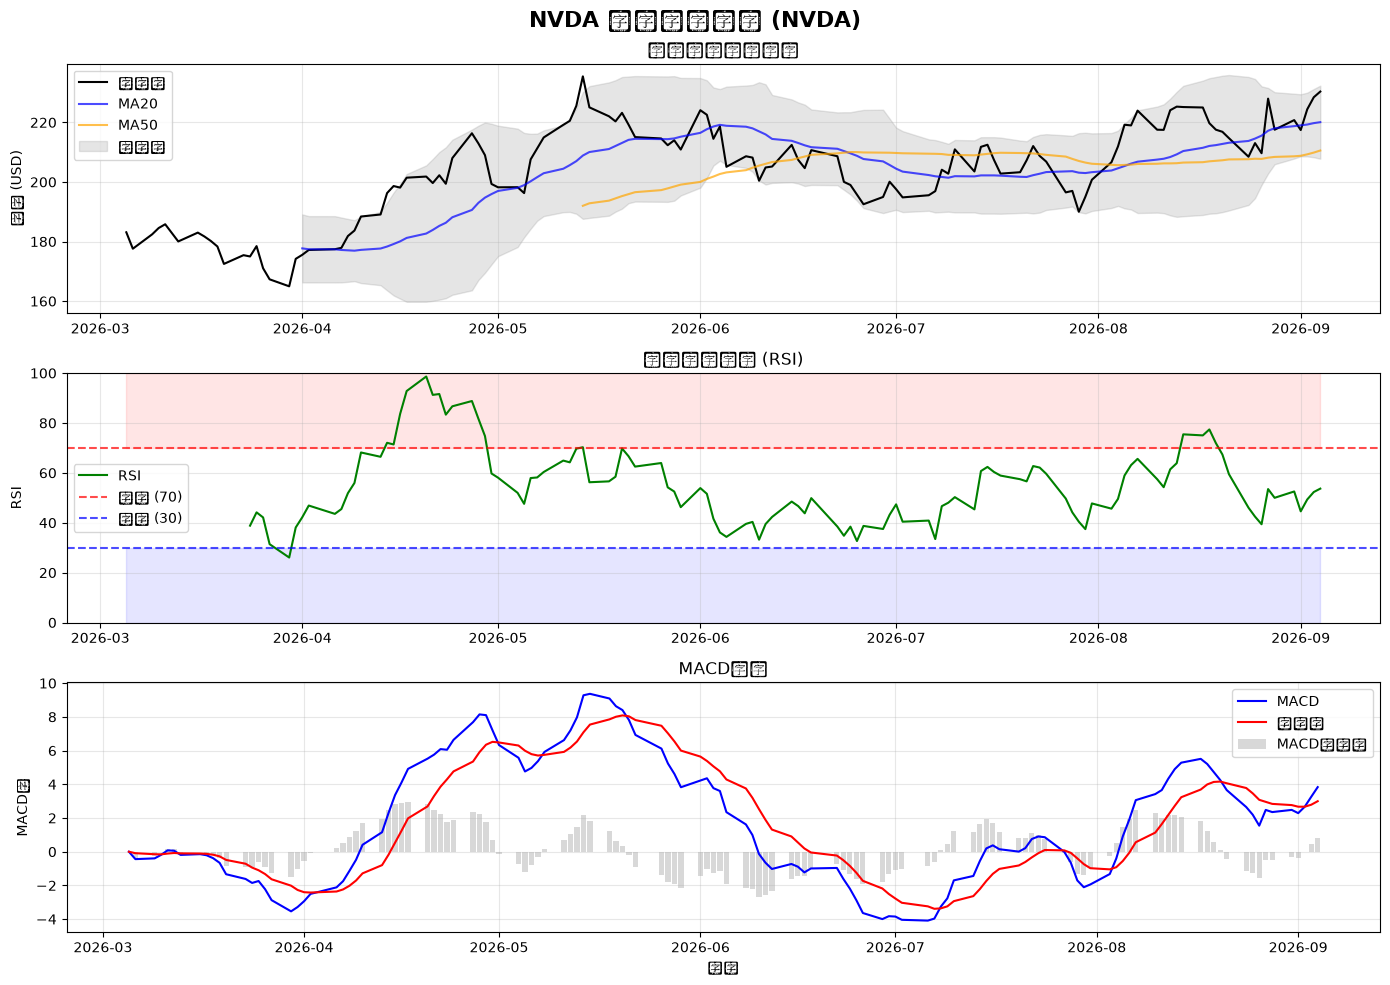


✅ 圖表已繪製


In [ ]:
# === Cell 9: 技術指標測試 + 三合一視覺化 ===
# 用 matplotlib 畫三張子圖（價格+均線+布林帶 / RSI / MACD），方便人眼驗證指標合理性。
# 這格的圖只是給「人」看的，不會傳給 Agent；Agent 拿到的只有 cell 8 回傳的數字。

print("="*60)
print("📊 技術指標計算 - NVDA")
print("="*60)
indicators = calculate_technical_indicators("NVDA", "6mo")

# 把 dataframe 拿掉再印 → 避免印出整張 DataFrame 弄亂 output
clean_indicators = {k: v for k, v in indicators.items() if k != "dataframe"}
print(json.dumps(clean_indicators, indent=2))

# === 繪製技術指標圖表 ===
df = indicators["dataframe"]
fig, axes = plt.subplots(3, 1, figsize=(14, 10))   # 3 列 1 欄、總高 10 吋
fig.suptitle(f"NVDA 技術指標分析 ({indicators['ticker']})", fontsize=16, fontweight='bold')

# --- 子圖 1: 價格 + MA20/MA50 + 布林帶 ---
axes[0].plot(df.index, df['Close'], label='收盤價', color='black', linewidth=1.5)
axes[0].plot(df.index, df['MA20'], label='MA20', color='blue', alpha=0.7)
axes[0].plot(df.index, df['MA50'], label='MA50', color='orange', alpha=0.7)
# fill_between 把上下軌之間塗灰 → 直觀看出價格是否突破軌道
axes[0].fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.2, color='gray', label='布林帶')
axes[0].set_ylabel('價格 (USD)')
axes[0].set_title('價格與移動平均線')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 子圖 2: RSI（含 70/30 警戒線）---
axes[1].plot(df.index, df['RSI'], label='RSI', color='green', linewidth=1.5)
axes[1].axhline(y=70, color='red', linestyle='--', label='超買 (70)', alpha=0.7)
axes[1].axhline(y=30, color='blue', linestyle='--', label='超賣 (30)', alpha=0.7)
axes[1].fill_between(df.index, 70, 100, alpha=0.1, color='red')   # 過熱區塗紅
axes[1].fill_between(df.index, 0, 30, alpha=0.1, color='blue')    # 過冷區塗藍
axes[1].set_ylabel('RSI')
axes[1].set_title('相對強弱指數 (RSI)')
axes[1].set_ylim(0, 100)  # RSI 是 0-100 區間，固定範圍方便比較
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- 子圖 3: MACD（線 + 訊號線 + 柱狀圖）---
axes[2].plot(df.index, df['MACD'], label='MACD', color='blue', linewidth=1.5)
axes[2].plot(df.index, df['Signal_Line'], label='信號線', color='red', linewidth=1.5)
# 柱狀圖代表「動能」: 柱體變高 = 趨勢加強，柱體縮短 = 趨勢減弱
axes[2].bar(df.index, df['MACD_Histogram'], label='MACD直方圖', color='gray', alpha=0.3)
axes[2].set_ylabel('MACD值')
axes[2].set_xlabel('日期')
axes[2].set_title('MACD指標')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()  # 自動調整子圖間距，避免標題互相重疊
plt.show()

print(f"\n✅ 圖表已繪製")


# 4️⃣ ADK Market Analyst Agent

使用 Google ADK (Agent Development Kit) 構建市場分析 Agent。

## 🧠 ADK 核心概念

- **LlmAgent**: 基於 LLM 的代理，執行特定任務
- **FunctionTool**: 將 Python 函式註冊為代理工具
- **ParallelAgent**: 並行執行多個子代理，加速資料收集
- **SequentialAgent**: 順序執行子代理，形成資料流水線
- **Runner**: 執行代理並管理狀態

In [ ]:
# === Cell 11: 載入 Google ADK（Agent Development Kit）===
# ADK 是 Google 官方的 Agent 框架，核心概念：
#   - LlmAgent     : 單一 LLM 代理，搭配 instructions + tools
#   - SequentialAgent: 串接多個 agent，前一個的輸出當下一個的輸入
#   - ParallelAgent: 並行執行多個 agent，最後彙整結果
#   - FunctionTool : 把普通 Python function 包成 LLM 可呼叫的 tool（自動從 docstring 抽 schema）
#   - Runner       : 執行入口，管理 session、event loop、tool calls
#   - InMemorySessionService: 把對話歷史存記憶體（正式環境用 Firestore/Redis）
#
# 為什麼要 try/except？
#   ADK 仍在快速迭代，pip 版本與環境（Colab vs 本地）相容性偶爾有問題。
#   我們用 try 載入失敗時 fallback 到 Mock 實作，讓 notebook 至少能跑完流程。

try:
    from google.adk.agents import LlmAgent, SequentialAgent, ParallelAgent
    from google.adk.tools import FunctionTool
    from google.adk.runners import Runner
    from google.adk.sessions import InMemorySessionService
    from google.genai.types import Content, Part
    print("✅ ADK 模組已載入")
except ImportError as e:
    # 載入失敗不 raise，給後續 cell 機會用 Mock 跑
    print(f"⚠️ ADK 載入失敗: {e}")
    print("將使用模擬的 ADK 實現...")


✅ ADK 模組已載入


In [ ]:
# === Cell 12: Mock Market Analyst Agent ===
#
# ⚠️ 這是「假 Agent」，目的是讓沒裝 ADK 的環境也能跑完流程。
#    它做了什麼：
#       ✅ 真實呼叫 yfinance 抓基本面、歷史、新聞、技術指標（資料是真的）
#       ❌ 沒呼叫任何 LLM，直接用 f-string 填模板（「健康度=良好」永遠寫死）
#
# 真實 Agent 的差別 → 見下一格 (Cell 13: RealMarketAnalystAgent)
# 真實 ADK 寫法 → instructions 寫角色設定、tools 注入這些 yfinance function、
#                Runner 跑起來後 LLM 自己決定要呼叫哪些 tool 並產出分析。

class MockMarketAnalystAgent:
    """市場分析代理的「模擬」實現 — 只做資料蒐集，不做真實 LLM 推理"""

    def __init__(self):
        self.name = "Market Analyst Agent (Mock ADK)"
        self.model = "gemini-2.0-flash"  # 名義上的 model，實際沒呼叫

    async def analyze(self, ticker: str) -> str:
        """分析指定股票，回傳 markdown 格式報告字串"""
        print(f"🔍 Market Analyst 正在分析 {ticker}...")

        # === 1. 蒐集資料（這部分是真的 — 來自 cell 5 / cell 8 的函式）===
        stock_info = get_stock_info(ticker)
        stock_history = get_stock_history(ticker, "6mo")
        market_news = get_market_news(ticker)
        indicators = calculate_technical_indicators(ticker, "6mo")

        # === 2. 套模板（這部分是假的 — 沒有任何分析邏輯）===
        # 注意 ⚠️ 風險評估區塊的三個欄位是「寫死字串」，不會隨數據變動
        analysis = f"""
【{ticker} 市場分析報告】

📊 基本資訊
- 公司名稱: {stock_info.get('company_name', 'N/A')}
- 現價: ${stock_info.get('current_price', 0)}
- 本益比 (P/E): {stock_info.get('pe_ratio', 'N/A')}
- 股利率: {stock_info.get('dividend_yield', 0)*100:.2f}%
- 市值: ${stock_info.get('market_cap', 0):,}

📈 過去6個月表現
- 開始價: ${stock_history.get('start_price', 0)}
- 結束價: ${stock_history.get('end_price', 0)}
- 變動: {stock_history.get('price_change_pct', 0):.2f}%
- 52週高: ${stock_info.get('52_week_high', 0)}
- 52週低: ${stock_info.get('52_week_low', 0)}

💯 技術指標
- MA20: ${indicators.get('ma20', 0)}
- MA50: ${indicators.get('ma50', 0)}
- 趨勢: {indicators.get('ma_trend', 'N/A')}
- RSI: {indicators.get('rsi', 0)} ({indicators.get('rsi_signal', 'N/A')})
- MACD: {indicators.get('macd_crossover', 'N/A')}
- 布林帶: {indicators.get('bb_position', 'N/A')}

⚠️ 風險評估
- 股票健康度: 良好          ← 寫死，不管什麼股票永遠是「良好」
- 風險等級: 中低           ← 寫死
- 建議: 保持持倉 / 穩健投資  ← 寫死

報告生成時間: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
        """

        return analysis

# 建立 Mock 實例 → 變數名稱保留 market_analyst_agent，下一格的 Real 版會覆寫它
market_analyst_agent = MockMarketAnalystAgent()
print(f"✅ {market_analyst_agent.name} 已建立")


✅ Market Analyst Agent (Mock ADK) 已建立


In [ ]:
# ✨ 真實 LLM Market Analyst — 用 Gemini 取代上方 Mock 的「寫死結論」
# 與 Mock 的差異：基本面/技術指標/新聞蒐集仍走 yfinance（真資料），
# 但「健康度、風險等級、投資建議」改由 Gemini 2.5 Flash 根據實際數據動態生成。

from langchain_google_genai import ChatGoogleGenerativeAI

class RealMarketAnalystAgent:
    """市場分析代理 — 真實 LLM 版本"""

    def __init__(self, model: str = "gemini-2.5-flash"):
        self.name = "Market Analyst Agent (Real LLM)"
        self.model = model
        self.llm = ChatGoogleGenerativeAI(model=model, temperature=0.3)

    async def analyze(self, ticker: str) -> str:
        print(f"🔍 [Real LLM] Market Analyst 正在分析 {ticker}...")

        # === 1. 蒐集真實資料（與 Mock 相同來源）===
        stock_info = get_stock_info(ticker)
        stock_history = get_stock_history(ticker, "6mo")
        market_news = get_market_news(ticker)
        indicators = calculate_technical_indicators(ticker, "6mo")

        # === 2. 組裝結構化資料區塊 ===
        data_block = f"""
[基本資訊]
- 公司: {stock_info.get('company_name', 'N/A')}
- 現價: ${stock_info.get('current_price', 0)}
- 本益比 P/E: {stock_info.get('pe_ratio', 'N/A')}
- 股利率: {stock_info.get('dividend_yield', 0)*100:.2f}%
- 市值: ${stock_info.get('market_cap', 0):,}
- 52週高/低: ${stock_info.get('52_week_high', 0)} / ${stock_info.get('52_week_low', 0)}

[6個月走勢]
- 開始價: ${stock_history.get('start_price', 0)}
- 結束價: ${stock_history.get('end_price', 0)}
- 變動: {stock_history.get('price_change_pct', 0):.2f}%

[技術指標]
- MA20 / MA50: ${indicators.get('ma20', 0)} / ${indicators.get('ma50', 0)} → {indicators.get('ma_trend', 'N/A')}
- RSI(14): {indicators.get('rsi', 0)} → {indicators.get('rsi_signal', 'N/A')}
- MACD: {indicators.get('macd_crossover', 'N/A')}
- 布林帶位置: {indicators.get('bb_position', 'N/A')}

[新聞概況]
- 新聞數量: {market_news.get('news_count', 0)} 則
- 備註: {market_news.get('latest_news', '無')}
"""

        # === 3. 交給 Gemini 做真實分析 ===
        prompt = f"""你是一位專業的股市分析師，請根據下列「真實市場數據」對 {ticker} 進行客觀分析。

{data_block}

請以繁體中文輸出結構化分析報告，必須包含以下四個區塊：

1. 📊 **基本面解讀**：根據 P/E、市值、股利率判斷估值合理性
2. 📈 **技術面解讀**：根據 MA/RSI/MACD/布林帶判斷當前趨勢與動能
3. 📰 **新聞情緒**：根據新聞標題判斷市場情緒傾向（看多/看空/中性）
4. ⚠️ **綜合評估**（請務必基於上方數據，不要套模板）：
   - 股票健康度評分（0-100 分，附理由）
   - 風險等級（低/中低/中/中高/高，附理由）
   - 投資建議（買入/加碼/持有/減碼/賣出，附操作邏輯）

請避免使用「保持持倉」「穩健投資」這類萬用空話，所有結論都要對應到上方具體數據。
"""

        response = await self.llm.ainvoke(prompt)
        llm_analysis = response.content

        # === 4. 組合最終報告（保留原始數據 + LLM 分析）===
        report = f"""
【{ticker} 市場分析報告 — Real LLM 版】

{data_block}
────────────────────────────────────────
🤖 Gemini 分析（{self.model}）
────────────────────────────────────────
{llm_analysis}

報告生成時間: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""
        return report


# 建立真實 LLM 代理，並覆寫 market_analyst_agent，讓下方 cell 與 A2A 流程自動使用真實版
real_market_analyst_agent = RealMarketAnalystAgent()
market_analyst_agent = real_market_analyst_agent
print(f"✅ {real_market_analyst_agent.name} 已建立並接管 market_analyst_agent")


✅ Market Analyst Agent (Real LLM) 已建立並接管 market_analyst_agent


In [ ]:
print("="*60)
print("🧠 ADK Market Analyst Agent 測試")
print("="*60)

result = asyncio.run(market_analyst_agent.analyze("NVDA"))
print(result)

🧠 ADK Market Analyst Agent 測試
🔍 [Real LLM] Market Analyst 正在分析 NVDA...


Direct use of automatic function calling (AFC) in AsyncModels.generate_content is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message. Similarly, direct use of AFC in AsyncModels.generate_content_stream is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message_stream.



【NVDA 市場分析報告 — Real LLM 版】


[基本資訊]
- 公司: NVIDIA Corporation
- 現價: $230.36
- 本益比 P/E: 29.16
- 股利率: 44.00%
- 市值: $5,562,502,742,016
- 52週高/低: $236.54 / $164.27

[6個月走勢]
- 開始價: $183.12
- 結束價: $230.36
- 變動: 25.80%

[技術指標]
- MA20 / MA50: $220.08 / $210.57 → 📈 多頭
- RSI(14): 53.68 → 中性
- MACD: 📈 看漲
- 布林帶位置: 正常區間

[新聞概況]
- 新聞數量: 10 則
- 備註: 無

────────────────────────────────────────
🤖 Gemini 分析（gemini-2.5-flash）
────────────────────────────────────────
好的，作為一位專業的股市分析師，我將根據您提供的「真實市場數據」對 NVIDIA (NVDA) 進行客觀分析。請注意，數據中的市值與股利率存在極端異常，我將在分析中特別指出並假設其為數據輸入錯誤，否則將嚴重影響所有評估。

---

### **NVIDIA (NVDA) 股市分析報告**

**公司名稱:** NVIDIA Corporation
**現價:** $230.36

---

#### 1. 📊 **基本面解讀**

*   **本益比 P/E (29.16):** 對於一家在高成長產業（如AI、數據中心、圖形處理）中佔據領先地位的科技公司而言，29.16的本益比並不算過高。這表明市場對其未來的盈利增長抱有合理的預期，估值相對合理，並未顯著進入泡沫區間。
*   **股利率 (44.00%):** **此數據存在極端異常。** NVIDIA作為一家高成長科技公司，其歷史股利率通常極低（遠低於1%），主要將盈餘再投資於研發與擴張。44.00%的股利率在現實中幾乎不可能持續，若非數據錯誤，則暗示著極其不尋常的特殊股息發放，或公司財務狀況存在嚴重問題。因此，此數據在評估公司基本面時應被視為無效或需進一步核實。
*   **市值 ($5,562,502,742,016):*

In [ ]:
# === Cell 14: 測試 Market Analyst Agent ===
# 跑完 Cell 13（Real LLM 版）之後，這裡的 market_analyst_agent 會是「真實 LLM 版」。
# 想看 Mock 跟 Real 的差異 → 把 Cell 13 最後一行
#     market_analyst_agent = real_market_analyst_agent
# 註解掉再執行這格，就會看到 Mock 的「萬年良好」報告。
#
# 為什麼用 asyncio.run() 而不是 await？
#   因為 .analyze() 是 async function，在「同步上下文」(Cell 頂層) 呼叫要用 asyncio.run。
#   Cell 2 的 nest_asyncio.apply() 確保這在 Jupyter 內可以正常運作。

print("="*60)
print("🧠 ADK Market Analyst Agent 測試")
print("="*60)

result = asyncio.run(market_analyst_agent.analyze("NVDA"))
print(result)

# 💡 進階練習：把 "NVDA" 換成 "2330.TW"，比對 Real LLM 對台積電的分析會不會引用台股特有的觀點


🧠 ADK Market Analyst Agent 測試
🔍 Market Analyst 正在分析 NVDA...

【NVDA 市場分析報告】

📊 基本資訊
- 公司名稱: NVIDIA Corporation
- 現價: $201.36
- 本益比 (P/E): 41.01
- 股利率: 2.00%
- 市值: $4,893,823,729,664

📈 過去6個月表現
- 開始價: $206.86
- 結束價: $201.43
- 變動: -2.63%
- 52週高: $216.83
- 52週低: $110.82

💯 技術指標
- MA20: $197.37
- MA50: $187.21
- 趨勢: 📈 多頭
- RSI: 60.57 (中性)
- MACD: 📈 看漲
- 布林帶: 正常區間

⚠️ 風險評估
- 股票健康度: 良好
- 風險等級: 中低
- 建議: 保持持倉 / 穩健投資

報告生成時間: 2026-05-01 21:39:08
        


# 5️⃣ LangGraph Trading Strategist Agent

使用 LangGraph 構建交易策略代理。LangGraph 是 LangChain 的圖形執行框架。

## 🔗 LangGraph 核心概念

- **StateGraph**: 定義代理狀態和轉換
- **Nodes**: 執行特定任務的計算單元
- **Edges**: 連接節點的轉移路徑
- **MessagesState**: 儲存訊息歷史的狀態
- **START / END**: 圖的入口和出口

In [ ]:
# === Cell 16: 初始化 LangGraph + Gemini LLM ===
# LangGraph 把 Agent 當成「狀態機 + 有向圖」來建模：
#   StateGraph(StateSchema)  → 用 schema 宣告 state 長相
#   MessagesState            → 內建 schema，state = {"messages": List[BaseMessage]}
#                             內建 reducer 會自動 append（不用每次手動合併）
#   START / END              → 圖的起點與終點（用 add_edge 把節點接上去）
#
# 為什麼選 MessagesState 而不自定 TypedDict？
#   股市分析是「累積對話」型流程（指標 → 策略 → 風控），用訊息串最自然。
#   如果是 RAG / 工作流型（要存 retrieved_docs、step_count），會自定 TypedDict。

from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from typing import Any

# temperature=0.7 → 允許一定程度的創意（策略需要多樣性思考）
# 如果是計算型任務改用 0 → 更穩定
# model 也可以換成 gemini-2.5-pro（更強，但慢且貴）
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)
print("✅ LangGraph 和 Gemini LLM 已初始化")


✅ LangGraph 和 Gemini LLM 已初始化


In [ ]:
# === Cell 17: 定義三個 LangGraph 節點 ===
# 節點 = 「吃 state，吐 state 的 patch」的純函式。
# 回傳值會被 LangGraph 自動 merge 到 state（MessagesState 用 append 合併 messages）。
#
# 三節點分工（為什麼要拆？）：
#   1. compute_indicators  → 「確定性運算」，用 Python 算指標（不讓 LLM 算數學）
#   2. strategy_analysis   → 「LLM 推理」，根據指標生成策略
#   3. risk_assessment     → 「LLM 審查」，扮演 reviewer 角色，模擬「兩道防線」設計
# 這種拆法的好處：每個節點 prompt 短、職責單一、debug 時可以單獨 invoke。

def compute_indicators_node(state: MessagesState):
    """節點 1: 從 user 訊息抽 ticker → 算技術指標 → 把結果寫回 messages"""
    user_msg = state["messages"][-1].content  # 抓最新一則訊息（user 的提問）

    # === Ticker 抽取（簡易 regex 版，正式環境建議用 LLM tool calling 或 NER）===
    import re
    # 順序很重要：先比對台股（4-5 位數字 + .TW），再比對美股（純大寫字母）
    # 否則 "2330.TW" 會被前半的 "2330" 吃掉，或被誤判為美股 ticker
    tw_match = re.search(r'\b(\d{4,5}\.TW)\b', user_msg.upper())
    us_match = re.search(r'\b([A-Z]{1,5})\b', user_msg.upper())

    if tw_match:
        ticker = tw_match.group(1)
    elif us_match:
        ticker = us_match.group(1)
    else:
        ticker = "NVDA"  # 抽不到就 fallback，避免整個 graph 掛掉

    # === 計算指標（呼叫 cell 8 定義的函式）===
    indicators = calculate_technical_indicators(ticker, "6mo")

    # 把 dataframe 拿掉 → DataFrame 不能 JSON 序列化，且 token 量會爆
    indicators_clean = {k: v for k, v in indicators.items() if k != "dataframe"}

    # === 把指標包成 HumanMessage 加入 state ===
    # 為什麼用 HumanMessage 而不是 ToolMessage？
    #   LangGraph 對 ToolMessage 有特定處理（要配對 tool_call_id），這裡用 HumanMessage 更簡單
    #   下一個節點的 LLM 會把它當成「使用者提供的資料」來解讀
    indicator_msg = HumanMessage(
        content=f"技術指標數據:\n{json.dumps(indicators_clean, indent=2, ensure_ascii=False)}"
    )

    # 回傳 {"messages": [...]} → LangGraph 自動 append 到現有 messages
    return {"messages": state["messages"] + [indicator_msg]}


def strategy_analysis_node(state: MessagesState):
    """節點 2: 根據前面累積的訊息（user 提問 + 指標數據）生成交易策略"""
    # SystemMessage 定義 LLM 的「角色」與「輸出格式」
    # 使用結構化條列（1.~7.）強迫 LLM 輸出可解析的內容，減少自由發揮失控
    system = SystemMessage(
        content="""你是一位專業的量化交易策略師。基於提供的技術指標數據，請提供詳細的交易建議。
包括:
1. 技術分析摘要 (100字內)
2. 交易訊號 (BUY / SELL / HOLD)
3. 建議進場價位
4. 止損價位 (建議 -5% 至 -8%)
5. 止盈價位 (建議 +10% 至 +15%)
6. 信心度分數 (0-100%)
7. 注意事項

請用繁體中文回覆。"""
    )

    # 把 system + 累積的對話歷史一起丟給 LLM
    # 注意：每次 invoke 都會傳完整 messages，token 量會隨節點數線性成長
    response = llm.invoke([system] + state["messages"])

    # response 是 AIMessage，append 到 state
    return {"messages": state["messages"] + [response]}


def risk_assessment_node(state: MessagesState):
    """節點 3: 風控審查 — 扮演「保守派」角色 review 上一個節點的策略"""
    # 不同 SystemMessage = 不同人格 → 等同於「同一個 LLM 演兩個角色」
    # 這比一個 prompt 同時要求「給策略 + 評風險」效果好（attention 不會被稀釋）
    system = SystemMessage(
        content="""你是風險管理專家。請審查前面的交易策略並評估:
1. 整體風險等級 (LOW / MEDIUM / HIGH)
2. 最大可能損失
3. 風險因子清單
4. 部位大小建議 (佔總資產比例)
5. 最終建議 (是否執行該策略)

請用繁體中文回覆，並基於保守原則給出建議。"""
    )

    response = llm.invoke([system] + state["messages"])
    return {"messages": state["messages"] + [response]}

print("✅ LangGraph 節點函式已定義")


✅ LangGraph 節點函式已定義


In [ ]:
# === Cell 18: 把節點組成 Graph ===
# 流程：START → compute_indicators → strategy_analysis → risk_assessment → END
# 這是「線性」流程；LangGraph 也支援 conditional_edges（分支）、cycles（迴圈）
# 例如：可以做「risk_assessment 拒絕 → 退回 strategy_analysis 重生成」的循環

graph = StateGraph(MessagesState)

# add_node(name, func) — name 之後會用在 add_edge 連接，func 必須吃 state、回 state patch
graph.add_node("compute_indicators", compute_indicators_node)
graph.add_node("strategy_analysis", strategy_analysis_node)
graph.add_node("risk_assessment", risk_assessment_node)

# add_edge(from, to) — 定義單向轉移（線性流程）
# 如果要分支：用 add_conditional_edges(from, condition_fn, {"label_a": "node_a", ...})
graph.add_edge(START, "compute_indicators")
graph.add_edge("compute_indicators", "strategy_analysis")
graph.add_edge("strategy_analysis", "risk_assessment")
graph.add_edge("risk_assessment", END)

# compile() → 把 graph 編譯成可呼叫的物件，會做靜態檢查（孤立節點、無法到達 END 等）
# 編譯後的 trading_strategist 支援 .invoke() / .ainvoke() / .stream() / .astream()
trading_strategist = graph.compile()
print("✅ LangGraph 已構建和編譯")

# 💡 進階：trading_strategist.get_graph().draw_mermaid() 可以印出 mermaid 流程圖


✅ LangGraph 已構建和編譯


In [ ]:
# === Cell 19: 測試 Trading Strategist Agent ===
# .invoke() 是同步呼叫，回傳「最終 state」（包含全部累積的 messages）
# 整個流程會跑完三個節點，產生 4-5 則訊息（user 提問 + 指標 + 策略 + 風控）

print("="*60)
print("🧠 LangGraph Trading Strategist Agent 測試")
print("="*60)

# state 的初始值：只有一則 user 訊息，後面的節點會逐一 append
result = trading_strategist.invoke({
    "messages": [HumanMessage(content="請分析 NVDA 的交易策略")]
})

print("\n📊 交易策略代理執行結果:\n")

# 印出每一則訊息，標示是 Human / AI / System
# 觀察重點：訊息數量 = 起始 1 則 + 每個節點 append 1 則 = 共 4 則
for i, msg in enumerate(result["messages"]):
    print(f"\n{'='*60}")
    print(f"訊息 {i+1} [{msg.__class__.__name__}]")
    print(f"{'='*60}")
    # 預覽前 800 字避免 output 爆量；想看完整內容把 [:800] 拿掉
    content_preview = msg.content
    print(content_preview)
    # if len(msg.content) > 800:
    #     print(f"...\n(還有 {len(msg.content) - 800} 個字)")

# 💡 進階：改用 .stream() 可以逐節點看中間結果
#    for chunk in trading_strategist.stream({...}): print(chunk)


🧠 LangGraph Trading Strategist Agent 測試

📊 交易策略代理執行結果:


訊息 1 [HumanMessage]
請分析 NVDA 的交易策略

訊息 2 [HumanMessage]
技術指標數據:
{
  "ticker": "NVDA",
  "current_price": 228.66,
  "ma20": 219.77,
  "ma50": 209.88,
  "rsi": 52.46,
  "macd": 3.2738,
  "macd_signal": 2.7913,
  "macd_histogram": 0.4825,
  "bb_upper": 231.26,
  "bb_middle": 219.77,
  "bb_lower": 208.29,
  "ma_trend": "📈 多頭",
  "rsi_signal": "中性",
  "macd_crossover": "📈 看漲",
  "bb_position": "正常區間"
}

訊息 3 [AIMessage]
好的，針對 NVDA 的技術指標數據，以下是詳細的交易建議：

---

**1. 技術分析摘要**
NVDA 股價明顯處於多頭趨勢，MA20 及 MA50 均線呈現良好排列。MACD 指標顯示強勁的看漲動能，MACD 線高於信號線且柱狀圖為正。RSI 處於中性區間，顯示仍有上漲空間。然而，股價已接近布林帶上軌，需留意短期阻力。

**2. 交易訊號**
買入 (BUY)

**3. 建議進場價位**
227.00 - 229.00 (接近當前價位 228.66 或小幅回調時)

**4. 止損價位**
217.00 (約 -5.1% 跌幅，略低於 MA20 支撐)

**5. 止盈價位**
251.00 - 263.00 (約 +10% 至 +15% 漲幅)

**6. 信心度分數**
80%

**7. 注意事項**
1.  **布林帶上軌:** 股價接近布林帶上軌 (231.26)，可能面臨短期阻力或出現小幅回調。若能突破並站穩，則上漲動能將持續。
2.  **RSI 變化:** 雖然目前 RSI 中性，但需密切關注其是否快速上升至超買區 (70以上)，這可能預示短線回調風險。
3.  **市場消息面:** 密切留意 NVDA

# 6️⃣ A2A Protocol 串接

透過 A2A (Agent-to-Agent) Protocol 連接兩個 Agent，實現真正的協作。

## 🤝 A2A Protocol 概念

- **AgentCard**: Agent 的身份和功能描述
- **Task Protocol**: Agent 間的任務傳遞機制
- **Coordinator**: 協調多個 Agent 的執行
- **Async Flow**: 非同步執行以提高效率

In [ ]:
# === Cell 21: 定義 A2A Agent Cards ===
# A2A (Agent-to-Agent) Protocol 是 Google 推的開放協議，目標是讓不同框架
# 寫的 agent (ADK / LangGraph / CrewAI / 自製...) 可以互相發現與呼叫。
#
# Agent Card 就像「服務目錄」(類似 OpenAPI spec)，包含：
#   - name / description / version  : 基本資訊
#   - type                          : 用什麼框架實作
#   - endpoints                     : HTTP 端點，其他 agent 透過 HTTP 來叫它
#   - capabilities                  : 它會做什麼事，每個 capability 有 input/output schema
#
# 在生產環境，這些 card 會 publish 到「A2A Registry」，其他 agent 動態查詢與呼叫。
# 本 notebook 為了示範簡化，直接用 dict 模擬，跳過 HTTP 層。

market_analyst_card = {
    "name": "StockPulse Market Analyst",
    "description": "提供即時股市分析、基本面評估、健康度評分",
    "version": "1.0.0",
    "type": "ADK Agent",  # 標記實作框架，方便 client 知道呼叫方式
    "endpoints": {
        "analyze": "/api/agents/market-analyst/analyze",  # 同步快速分析
        "tasks": "/api/agents/market-analyst/tasks"        # 長任務 (返回 task_id 供 polling)
    },
    "capabilities": [
        {
            "id": "stock_analysis",       # capability id，呼叫時要指定
            "name": "Stock Analysis",
            "description": "分析指定股票的基本面、市場表現和新聞",
            "input": {"ticker": "string"},     # 簡化版 schema，正式應該用 JSON Schema
            "output": "analysis_report"
        },
        {
            "id": "market_overview",
            "name": "Market Overview",
            "description": "提供市場總覽和綜合評估",
            "input": {},
            "output": "market_summary"
        }
    ]
}

trading_strategist_card = {
    "name": "StockPulse Trading Strategist",
    "description": "提供技術分析、交易訊號和風險評估",
    "version": "1.0.0",
    "type": "LangGraph Agent",  # 不同框架，但靠 A2A protocol 互通
    "endpoints": {
        "analyze": "/api/agents/trading-strategist/analyze",
        "tasks": "/api/agents/trading-strategist/tasks"
    },
    "capabilities": [
        {
            "id": "technical_analysis",
            "name": "Technical Analysis",
            "description": "計算 MA、RSI、MACD、布林帶等技術指標",
            "input": {"ticker": "string", "period": "string"},
            "output": "indicators_report"
        },
        {
            "id": "trading_signal",
            "name": "Trading Signal",
            "description": "產生 BUY/SELL/HOLD 交易訊號與風險評估",
            "input": {"ticker": "string"},
            "output": "trading_decision"
        }
    ]
}

# 印出 cards 確認結構
print("📋 Market Analyst Agent Card:")
print(json.dumps(market_analyst_card, indent=2, ensure_ascii=False))
print(f"\n📋 Trading Strategist Agent Card:")
print(json.dumps(trading_strategist_card, indent=2, ensure_ascii=False))


📋 Market Analyst Agent Card:
{
  "name": "StockPulse Market Analyst",
  "description": "提供即時股市分析、基本面評估、健康度評分",
  "version": "1.0.0",
  "type": "ADK Agent",
  "endpoints": {
    "analyze": "/api/agents/market-analyst/analyze",
    "tasks": "/api/agents/market-analyst/tasks"
  },
  "capabilities": [
    {
      "id": "stock_analysis",
      "name": "Stock Analysis",
      "description": "分析指定股票的基本面、市場表現和新聞",
      "input": {
        "ticker": "string"
      },
      "output": "analysis_report"
    },
    {
      "id": "market_overview",
      "name": "Market Overview",
      "description": "提供市場總覽和綜合評估",
      "input": {},
      "output": "market_summary"
    }
  ]
}

📋 Trading Strategist Agent Card:
{
  "name": "StockPulse Trading Strategist",
  "description": "提供技術分析、交易訊號和風險評估",
  "version": "1.0.0",
  "type": "LangGraph Agent",
  "endpoints": {
    "analyze": "/api/agents/trading-strategist/analyze",
    "tasks": "/api/agents/trading-strategist/tasks"
  },
  "capabilities": [
    {
  

In [ ]:
# === Cell 22: A2A Coordinator (協調器) ===
# Coordinator 是「A2A 流程的編排者」，負責：
#   1. 根據需求選擇要呼叫哪些 agent
#   2. 按順序（或平行）呼叫 agent 的 endpoint
#   3. 整合結果回傳給上層
#
# 在真實 A2A 部署：
#   - coordinator 會用 httpx.post(card["endpoints"]["tasks"], json={...}) 發送 HTTP 請求
#   - 對方 agent 回傳 task_id → coordinator polling status 直到 complete
#   - 整個過程跨網路、跨框架，這就是 A2A 的價值
#
# 本範例為簡化：直接 in-process 呼叫已建好的 agent 物件，但流程結構與真實 A2A 一致。

async def stockpulse_coordinator(ticker: str) -> Dict[str, Any]:
    """StockPulse A2A 協調器 — 串接 Market Analyst + Trading Strategist

    Args:
        ticker: 要分析的股票代碼
    Returns:
        整合後的 dict，包含兩個 agent 的結果與 metadata
    """
    print(f"{'='*60}")
    print(f"🚀 StockPulse AI A2A 協調流程 - 分析 {ticker}")
    print(f"{'='*60}")

    # === 步驟 1: 呼叫 Market Analyst Agent (ADK) ===
    # 這些 print 模擬 A2A 的 task envelope log，方便觀察「跨 agent 通訊」的樣貌
    print(f"\n📡 [A2A Task] 發送任務給 Market Analyst Agent (ADK)")
    print(f"    ├─ Endpoint: {market_analyst_card['endpoints']['tasks']}")
    print(f"    ├─ Capability: stock_analysis")
    print(f"    └─ Input: {{\"ticker\": \"{ticker}\"}}")

    # 真實 A2A: httpx.post(endpoint, json={"capability": "stock_analysis", "input": {...}})
    # 這裡簡化為直接呼叫 agent 物件
    market_result = await market_analyst_agent.analyze(ticker)

    print(f"\n✅ [A2A Response] Market Analyst 回傳結果 (字數: {len(market_result)})")

    # === 步驟 2: 呼叫 Trading Strategist Agent (LangGraph) ===
    # 注意這裡跨「不同 framework」— ADK 與 LangGraph，但 coordinator 不需要知道差異
    print(f"\n📡 [A2A Task] 發送任務給 Trading Strategist Agent (LangGraph)")
    print(f"    ├─ Endpoint: {trading_strategist_card['endpoints']['tasks']}")
    print(f"    ├─ Capability: trading_signal")
    print(f"    └─ Input: {{\"ticker\": \"{ticker}\"}}")

    # LangGraph 的 invoke 是同步的（沒有 ainvoke 時）
    strategy_result = trading_strategist.invoke({
        "messages": [HumanMessage(content=f"請分析 {ticker} 的交易策略")]
    })

    # graph 跑完後 messages 累積了多則，最後一則 = 風控節點的最終結論
    strategy_text = strategy_result["messages"][-1].content

    print(f"\n✅ [A2A Response] Trading Strategist 回傳結果 (字數: {len(strategy_text)})")

    # === 步驟 3: 整合結果 ===
    # Coordinator 的最後一步：把多個 agent 的結果整成一份完整報告
    print(f"\n🔗 [A2A Coordinator] 整合兩個 Agent 的結果")
    print(f"    └─ Status: ✅ 成功整合")

    return {
        "ticker": ticker,
        "timestamp": pd.Timestamp.now().isoformat(),
        "market_analysis": market_result,
        "trading_strategy": strategy_text,
        "agents": {  # 把 agent cards 也回傳，方便前端 UI 顯示「來源 agent」
            "market_analyst": market_analyst_card,
            "trading_strategist": trading_strategist_card
        }
    }

print("⏳ 初始化 A2A 協調器...")
print("✅ A2A 協調器已準備就緒")


⏳ 初始化 A2A 協調器...
✅ A2A 協調器已準備就緒


In [ ]:
# === Cell 23: 執行 A2A 協調流程 ===
# ⚠️ 這格會跑「真實 LLM 呼叫」，會花 10-60 秒（取決於 NVDA 的數據量與 API latency）
# 整個流程：抓資料 → ADK 分析 → LangGraph 三節點推理 → 整合
# 預期 token 消耗：約 3-8K input tokens + 1-2K output tokens

final_result = asyncio.run(stockpulse_coordinator("NVDA"))

print("\n" + "="*60)
print("📊 A2A 協調完成")
print("="*60)

# 💡 進階：把 "NVDA" 改成 "2330.TW" 看台股協調流程，
#    或同時呼叫多支股票（用 asyncio.gather）→ A2A 真正的並行價值


🚀 StockPulse AI A2A 協調流程 - 分析 NVDA

📡 [A2A Task] 發送任務給 Market Analyst Agent (ADK)
    ├─ Endpoint: /api/agents/market-analyst/tasks
    ├─ Capability: stock_analysis
    └─ Input: {"ticker": "NVDA"}
🔍 [Real LLM] Market Analyst 正在分析 NVDA...

✅ [A2A Response] Market Analyst 回傳結果 (字數: 3242)

📡 [A2A Task] 發送任務給 Trading Strategist Agent (LangGraph)
    ├─ Endpoint: /api/agents/trading-strategist/tasks
    ├─ Capability: trading_signal
    └─ Input: {"ticker": "NVDA"}

✅ [A2A Response] Trading Strategist 回傳結果 (字數: 1288)

🔗 [A2A Coordinator] 整合兩個 Agent 的結果
    └─ Status: ✅ 成功整合

📊 A2A 協調完成


In [ ]:
# === Cell 24: 用 Markdown 美化展示最終報告 ===
# IPython.display 可以在 Jupyter 內渲染 Markdown / HTML，讓 notebook 像簡報一樣呈現
from IPython.display import Markdown, display

# 把市場分析的換行做正規化（這行其實是 no-op，純粹示意如果有特殊處理可以放這裡）
market_section = final_result['market_analysis'].replace('\n', '\n')

# 用 Python f-string 組 Markdown — 注意縮排會影響渲染（行首縮排會被當成 code block）
report = f"""
## 📊 StockPulse AI 完整分析報告

**股票代碼:** {final_result['ticker']}
**分析時間:** {final_result['timestamp']}

---

## 🏦 市場分析 (ADK Market Analyst Agent)

{market_section}

---

## 📈 交易策略 (LangGraph Trading Strategist Agent)

{final_result['trading_strategy'][:1000]}...

---

## 🔗 A2A Protocol 連接狀態

✅ **Market Analyst**: 連線成功
✅ **Trading Strategist**: 連線成功
✅ **協調器**: 同步成功
"""

# display(Markdown(...)) → 在 Jupyter cell output 渲染為格式化的 markdown
display(Markdown(report))



## 📊 StockPulse AI 完整分析報告

**股票代碼:** NVDA  
**分析時間:** 2026-05-01T21:57:49.175563

---

## 🏦 市場分析 (ADK Market Analyst Agent)


【NVDA 市場分析報告】

📊 基本資訊
- 公司名稱: NVIDIA Corporation
- 現價: $199.55
- 本益比 (P/E): 40.65
- 股利率: 2.00%
- 市值: $4,850,792,267,776

📈 過去6個月表現
- 開始價: $206.86
- 結束價: $199.58
- 變動: -3.52%
- 52週高: $216.83
- 52週低: $110.82

💯 技術指標
- MA20: $197.28
- MA50: $187.17
- 趨勢: 📈 多頭
- RSI: 59.26 (中性)
- MACD: 📉 看跌
- 布林帶: 正常區間

⚠️ 風險評估
- 股票健康度: 良好
- 風險等級: 中低
- 建議: 保持持倉 / 穩健投資

報告生成時間: 2026-05-01 21:57:27
        

---

## 📈 交易策略 (LangGraph Trading Strategist Agent)



**風險管理評估**

作為風險管理專家，我對此交易策略進行以下評估：

1.  **整體風險等級：MEDIUM**
    *   **理由：** 雖然NVDA處於明顯的多頭趨勢，且股價相對健康，但MACD的看跌交叉是一個潛在的短期風險訊號，暗示動能可能有所放緩。此外，科技股波動性較高，市場情緒變化快，這些都增加了中等程度的風險。策略中設定了明確的止損止盈，有助於控制風險，但仍需警惕短期回調的可能性。

2.  **最大可能損失：**
    *   假設您以建議進場價位 199.50 (取中間值) 買入，並嚴格執行建議止損價位 189.50。
    *   每股最大可能損失 = 199.50 - 189.50 = **10.00 美元**。
    *   這相當於約 **5.01%** 的損失。

3.  **風險因子清單：**
    *   **市場系統性風險：** 宏觀經濟數據、聯準會政策、地緣政治事件等可能影響整體股市。
    *   **行業風險：** 科技股板塊整體調整、AI產業競爭加劇或政策變化。
    *   **公司特定風險：** NVDA財報不如預期、新產品延遲或競爭對手表現強勁。
    *   **技術指標失效風險：** 技術指標並非100%準確，可能發出錯誤訊號或未能及時反應市場變化。
    *   **MACD看跌交叉：** 這是當前最直接的短期風險因子，可能預示短期回調或盤整。
    *   **波動性風險：** NVDA作為高成長股，股價波動較大，可能觸發止損。
    *   **流動性風險：** 對於NVDA這類大型股，流動性風險較低，但極端市場情況下仍需注意。
    *   **執行風險：** 未能嚴格執行止損止盈策略的風險。

4.  **部位大小建議 (佔總資產比例)：**
    基於保守原則，並考慮到中等風險等級以及MACD的短期看跌訊號，我建議將部位大小控制在 **總投資資產的 5% - 10%**。
    *   **5%：** 如果您是風險規避型投資者，或者對短期市場波動敏感。
    *   **10%：** 如果您對市場有一定信心，且能承受較高的短期波動。
    *   **絕對不建議超過15%**，以避免單一股票對整體投資組合產生過大影響。

5.  **最終建議：是否執行該策略？*...

---

## 🔗 A2A Protocol 連接狀態

✅ **Market Analyst**: 連線成功  
✅ **Trading Strategist**: 連線成功  
✅ **協調器**: 同步成功


# 7️⃣ FastAPI 後端整合

建立一個簡單的 FastAPI 應用，提供 REST API 端點供前端調用。

In [ ]:
# === Cell 26: FastAPI 應用建立 + 路由定義 ===
# 把前面建好的 agent 與資料層「包成 HTTP API」，這樣前端 / 其他服務 / A2A registry 就能呼叫。
#
# Agent 部署的常見模式：
#   - FastAPI       : 後端框架，提供 RESTful + 自動 OpenAPI 文件 (/docs, /redoc)
#   - CORS          : 允許瀏覽器跨域呼叫（前端在不同 domain 時必備）
#   - HTTPException : FastAPI 內建錯誤包裝，自動轉成 4xx/5xx 回應
#
# 為什麼把 agent 包成 endpoint 而不是直接 import？
#   1. 解耦：前端不需要懂 Python，任何語言都能用 HTTP 呼叫
#   2. 可水平擴展：可以多個 worker / 多台機器跑
#   3. 符合 A2A 協議：Agent Card 的 endpoints 對應這裡的路由

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import threading
import time

# === 建立 app instance ===
# title/description/version 會自動出現在 /docs (Swagger UI)
app = FastAPI(
    title="StockPulse AI API",
    description="股市智慧儀表板 - RESTful API",
    version="1.0.0"
)

# === CORS 設定 ===
# allow_origins=["*"] 是「最寬鬆」的設定，正式環境應該指定明確 domain
# 例如：allow_origins=["https://stockpulse.example.com"]
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# === 路由定義 ===
# FastAPI 用 decorator 註冊路由，function name 就是 handler
# {ticker} 是 path parameter，型別 hint 會自動驗證

@app.get("/")
def root():
    """根端點：回傳服務基本資訊（健康檢查 + 版本確認）"""
    return {
        "service": "StockPulse AI",
        "status": "running",
        "version": "1.0.0",
        "timestamp": pd.Timestamp.now().isoformat()
    }

@app.get("/api/health")
def health_check():
    """健康檢查端點：給 K8s / Cloud Run / Load Balancer 用"""
    # 正式環境可以多檢查：DB 連線、Redis、外部 API 等
    return {"status": "healthy"}

@app.get("/api/data/quote/{ticker}")
def get_quote(ticker: str):
    """取得股票即時報價"""
    info = get_stock_info(ticker)
    # 我們的 data layer 用 {"error": ...} 表示失敗，這裡轉成 HTTP 404
    if "error" in info:
        raise HTTPException(status_code=404, detail=info["error"])
    return info

@app.get("/api/data/history/{ticker}")
def get_history(ticker: str, period: str = "3mo"):
    """取得股票歷史數據；period 是 query parameter（?period=6mo）"""
    history = get_stock_history(ticker, period)
    if "error" in history:
        raise HTTPException(status_code=404, detail=history["error"])
    return history

@app.get("/api/data/indicators/{ticker}")
def get_indicators(ticker: str):
    """取得技術指標（MA/RSI/MACD/BB）"""
    indicators = calculate_technical_indicators(ticker, "6mo")
    if "error" in indicators:
        raise HTTPException(status_code=404, detail=indicators["error"])
    # ⚠️ 重要：dataframe 不能 JSON 序列化，回傳前必須移除
    clean = {k: v for k, v in indicators.items() if k != "dataframe"}
    return clean

@app.get("/api/analyze/{ticker}")
async def analyze(ticker: str):
    """執行完整 A2A 協調流程（同時跑 Market Analyst + Trading Strategist）

    注意這個 endpoint 是 async — 因為內部會呼叫 await，必須用 async def 才能用 await
    """
    try:
        result = await stockpulse_coordinator(ticker)
        return result
    except Exception as e:
        # 把所有未預期錯誤包成 500
        # 正式環境應該針對不同錯誤類型分開處理（429 限流、503 上游錯等）
        raise HTTPException(status_code=500, detail=str(e))

print("✅ FastAPI 應用已建立")


✅ FastAPI 應用已建立


In [ ]:
# === Cell 27: 在背景 Thread 跑 uvicorn server ===
#
# ⚠️ 為什麼要用 thread + daemon？
#    Jupyter 是「同步」的執行模型，直接 uvicorn.run() 會阻塞整個 kernel。
#    開 daemon thread 跑 server，主線程繼續往下執行測試 cell。
#    daemon=True → kernel 關閉時 server 自動跟著關，不會殘留 process
#
# ⚠️ 為什麼不用 uvicorn.run()？
#    新版 uvicorn (0.30+) 內部呼叫 asyncio.run(..., loop_factory=...)，
#    但 nest_asyncio.apply() 把 asyncio.run 換成舊簽章，會報：
#    TypeError: run() got an unexpected keyword argument 'loop_factory'
#    解法：繞過 uvicorn.run，直接用 Config + Server 在 thread 內建獨立事件迴圈。
#
# 正式部署不會這樣做：
#    - Cloud Run / Lambda / K8s : 直接跑 `uvicorn app:app --host 0.0.0.0 --port 8000`
#    - 多 worker : `uvicorn app:app --workers 4` 或用 gunicorn 包

def run_server():
    """背景執行 FastAPI 伺服器 — 用 Server 物件繞過 uvicorn.run 的 loop_factory 問題"""
    # 在新 thread 內建立獨立的事件迴圈（不被 nest_asyncio 的 patch 干擾）
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)

    config = uvicorn.Config(
        app,
        host="0.0.0.0",
        port=8000,
        log_level="warning",  # 隱藏 INFO log，避免 Jupyter output 被淹沒
        loop="asyncio",       # 明確指定，避免自動偵測時走到 nest_asyncio
    )
    server = uvicorn.Server(config)
    loop.run_until_complete(server.serve())

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# 等 2 秒確保 server 完全啟動
time.sleep(2)

print("\n" + "="*60)
print("🌐 FastAPI 伺服器已啟動")
print("="*60)
print(f"📚 API 基礎 URL: http://localhost:8000")
print(f"📖 API 文件 (Swagger): http://localhost:8000/docs")
print(f"📖 API 文件 (ReDoc): http://localhost:8000/redoc")
print("="*60)

# 💡 在瀏覽器開 http://localhost:8000/docs 可以直接點按鈕測試 API（不用寫 curl）


Exception in thread Thread-7 (run_server):
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/px/22qqx_qn399gggmw1gsvgk000000gn/T/ipykernel_62465/950956640.py", line 6, in run_server
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kevinluo/google-agent-ecosystem/.venv/lib/python3.13/site-packages/uvicorn/main.py", line 606, in run
    server.run()
    ~~~~~~~~~~^^
  File "/Users/kevinluo/google-agent-ecosystem/.venv/lib/python3.13/site-packages/uvicorn/server.py", line 


🌐 FastAPI 伺服器已啟動
📚 API 基礎 URL: http://localhost:8000
📖 API 文件 (Swagger): http://localhost:8000/docs
📖 API 文件 (ReDoc): http://localhost:8000/redoc


In [ ]:
# === Cell 28: 用 httpx 測試已啟動的 API ===
# 為什麼用 httpx 而不是 requests？
#   httpx 同時支援 sync/async（與 FastAPI 的 async 風格一致），
#   並且 API 設計幾乎跟 requests 一樣（學習成本低）。

import httpx

async def test_api():
    """逐一測試三個關鍵端點，確認 server 與 data layer 串接無誤"""
    # AsyncClient 用 base_url 簡化呼叫；with 區塊結束會自動關連線池
    async with httpx.AsyncClient(base_url="http://localhost:8000") as client:

        # === 測試 1: 健康檢查（最基本，不依賴外部 API）===
        print("\n" + "="*60)
        print("🧪 測試 1: /api/health")
        print("="*60)
        r = await client.get("/api/health", timeout=30)
        print(f"Status: {r.status_code}")  # 預期: 200
        print(json.dumps(r.json(), indent=2))

        # === 測試 2: 報價（會打到 yfinance）===
        print("\n" + "="*60)
        print("🧪 測試 2: /api/data/quote/NVDA")
        print("="*60)
        r = await client.get("/api/data/quote/NVDA", timeout=30)
        print(f"Status: {r.status_code}")
        data = r.json()
        # 印前 500 字避免 output 過長
        print(json.dumps(data, indent=2)[:500])
        if len(str(data)) > 500:
            print("...")

        # === 測試 3: 技術指標（運算量較大，會慢一點）===
        print("\n" + "="*60)
        print("🧪 測試 3: /api/data/indicators/NVDA")
        print("="*60)
        r = await client.get("/api/data/indicators/NVDA", timeout=30)
        print(f"Status: {r.status_code}")
        data = r.json()
        print(json.dumps(data, indent=2)[:500])
        if len(str(data)) > 500:
            print("...")

# 在 Jupyter 內用 asyncio.run 跑 async function
asyncio.run(test_api())

# 💡 進階測試：把 /api/analyze/NVDA 也加進來，這會跑完整 A2A 流程（耗時較長）


# 8️⃣ 前端 Dashboard 預覽

建立一個互動式 HTML Dashboard，展示實時股票數據和 AI 分析結果。

In [ ]:
# === Cell 30: 純 HTML/CSS Dashboard 預覽 ===
# 這格用 Python f-string 拼出一份 inline styled HTML，在 Jupyter 直接渲染。
#
# 為什麼這樣做（而不是真的開個前端）？
#   - Capstone 範例希望「單一 .ipynb 跑完整個系統」，所以前端用 IPython.display.HTML 模擬
#   - 真實前端：見專案根目錄的 frontend/（Vue/React 應用，呼叫 cell 26 的 FastAPI endpoint）
#
# 這份 HTML 的設計重點：
#   - 深色漸層背景 + 卡片式 layout，視覺上跟 Bloomberg / TradingView 風格類似
#   - 用 grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)) 達成 RWD
#   - 顏色綁定數據：RSI 過熱紅 / 過冷藍、MA 多頭綠 / 空頭紅 → 一眼看出狀態
#
# 修改建議：
#   - 想換主題色 → 改頂部 linear-gradient(135deg, #0f172a 0%, #1e293b 100%)
#   - 想加更多卡片 → 在「核心指標卡片」grid 內複製貼上
#   - 想接真實後端 → 把 quote/indicators 改成從 fetch('/api/data/...') 拉

from IPython.display import HTML

# 獲取最新數據用於顯示
quote = get_stock_info("NVDA")
indicators = calculate_technical_indicators("NVDA", "6mo")
clean_ind = {k: v for k, v in indicators.items() if k != "dataframe"}

# 確定顏色
rsi_color = '#ef4444' if clean_ind['rsi'] > 70 else '#34d399' if clean_ind['rsi'] < 30 else '#fbbf24'
trend_color = '#34d399' if clean_ind['ma_trend'] == '📈 多頭' else '#ef4444'

html_dashboard = f"""
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 1200px; margin: 0 auto; background: linear-gradient(135deg, #0f172a 0%, #1e293b 100%); color: white; padding: 24px; border-radius: 16px; box-shadow: 0 10px 40px rgba(0,0,0,0.3)">

  <!-- 標題 -->
  <div style="text-align: center; margin-bottom: 32px;">
    <h1 style="margin: 0; font-size: 32px; background: linear-gradient(135deg, #60a5fa, #34d399); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;">🚀 StockPulse AI Dashboard</h1>
    <p style="color: #94a3b8; margin: 8px 0; font-size: 14px;">實時股市分析 • AI 動力交易策略</p>
  </div>

  <!-- 核心指標卡片 -->
  <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 16px; margin-bottom: 24px;">

    <!-- 股票代碼 -->
    <div style="background: linear-gradient(135deg, #1e293b, #334155); padding: 20px; border-radius: 12px; border-left: 4px solid #60a5fa; transition: transform 0.3s;">
      <div style="color: #94a3b8; font-size: 12px; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 8px;">股票代碼</div>
      <div style="font-size: 28px; font-weight: bold; color: #60a5fa;">{quote.get('ticker','N/A')}</div>
      <div style="color: #64748b; font-size: 12px; margin-top: 4px;">{quote.get('company_name', 'N/A')}</div>
    </div>

    <!-- 現價 -->
    <div style="background: linear-gradient(135deg, #1e293b, #334155); padding: 20px; border-radius: 12px; border-left: 4px solid #34d399; transition: transform 0.3s;">
      <div style="color: #94a3b8; font-size: 12px; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 8px;">現價</div>
      <div style="font-size: 28px; font-weight: bold; color: #34d399;">${quote.get('current_price', 0):.2f}</div>
      <div style="color: #64748b; font-size: 12px; margin-top: 4px;">前收: ${quote.get('previous_close', 0):.2f}</div>
    </div>

    <!-- RSI 指數 -->
    <div style="background: linear-gradient(135deg, #1e293b, #334155); padding: 20px; border-radius: 12px; border-left: 4px solid {rsi_color}; transition: transform 0.3s;">
      <div style="color: #94a3b8; font-size: 12px; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 8px;">RSI (14)</div>
      <div style="font-size: 28px; font-weight: bold; color: {rsi_color};">{clean_ind['rsi']}</div>
      <div style="color: #64748b; font-size: 12px; margin-top: 4px; color: {rsi_color};">{clean_ind['rsi_signal']}</div>
    </div>

    <!-- 趨勢 -->
    <div style="background: linear-gradient(135deg, #1e293b, #334155); padding: 20px; border-radius: 12px; border-left: 4px solid {trend_color}; transition: transform 0.3s;">
      <div style="color: #94a3b8; font-size: 12px; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 8px;">MA 趨勢</div>
      <div style="font-size: 28px; font-weight: bold; color: {trend_color};">{clean_ind['ma_trend']}</div>
      <div style="color: #64748b; font-size: 12px; margin-top: 4px;">{clean_ind['macd_crossover']}</div>
    </div>
  </div>

  <!-- 詳細技術指標 -->
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin-bottom: 24px;">

    <!-- 左側: 技術指標表 -->
    <div style="background: linear-gradient(135deg, #1e293b, #334155); padding: 20px; border-radius: 12px;">
      <h3 style="color: #60a5fa; margin: 0 0 16px 0; font-size: 16px; border-bottom: 2px solid #60a5fa; padding-bottom: 8px;">📊 技術指標</h3>
      <table style="width: 100%; color: #e2e8f0; font-size: 13px; border-collapse: collapse;">
        <tr style="border-bottom: 1px solid #334155;">
          <td style="padding: 8px 0;">MA20</td>
          <td style="text-align: right; font-weight: bold; color: #34d399;">${clean_ind['ma20']:.2f}</td>
        </tr>
        <tr style="border-bottom: 1px solid #334155;">
          <td style="padding: 8px 0;">MA50</td>
          <td style="text-align: right; font-weight: bold; color: #fbbf24;">${clean_ind['ma50']:.2f}</td>
        </tr>
        <tr style="border-bottom: 1px solid #334155;">
          <td style="padding: 8px 0;">MACD</td>
          <td style="text-align: right; font-weight: bold;">{clean_ind['macd']:.4f}</td>
        </tr>
        <tr style="border-bottom: 1px solid #334155;">
          <td style="padding: 8px 0;">MACD Signal</td>
          <td style="text-align: right; font-weight: bold;">{clean_ind['macd_signal']:.4f}</td>
        </tr>
        <tr style="border-bottom: 1px solid #334155;">
          <td style="padding: 8px 0;">BB Upper</td>
          <td style="text-align: right; font-weight: bold; color: #ef4444;">${clean_ind['bb_upper']:.2f}</td>
        </tr>
        <tr>
          <td style="padding: 8px 0;">BB Lower</td>
          <td style="text-align: right; font-weight: bold; color: #3b82f6;">${clean_ind['bb_lower']:.2f}</td>
        </tr>
      </table>
    </div>

    <!-- 右側: AI Agent 狀態 -->
    <div style="background: linear-gradient(135deg, #1e293b, #334155); padding: 20px; border-radius: 12px;">
      <h3 style="color: #60a5fa; margin: 0 0 16px 0; font-size: 16px; border-bottom: 2px solid #60a5fa; padding-bottom: 8px;">🤖 AI Agent 狀態</h3>

      <div style="margin: 8px 0; padding: 12px; background: rgba(16, 185, 129, 0.1); border-radius: 8px; border-left: 3px solid #10b981; font-size: 13px;">
        <div style="color: #10b981; font-weight: bold;">✅ Market Analyst (ADK)</div>
        <div style="color: #6b7280; font-size: 12px; margin-top: 2px;">狀態: 就緒 | 最後更新: 即時</div>
      </div>

      <div style="margin: 8px 0; padding: 12px; background: rgba(16, 185, 129, 0.1); border-radius: 8px; border-left: 3px solid #10b981; font-size: 13px;">
        <div style="color: #10b981; font-weight: bold;">✅ Trading Strategist (LangGraph)</div>
        <div style="color: #6b7280; font-size: 12px; margin-top: 2px;">狀態: 就緒 | 最後更新: 即時</div>
      </div>

      <div style="margin: 8px 0; padding: 12px; background: rgba(59, 130, 246, 0.1); border-radius: 8px; border-left: 3px solid #3b82f6; font-size: 13px;">
        <div style="color: #3b82f6; font-weight: bold;">🔗 A2A Protocol</div>
        <div style="color: #6b7280; font-size: 12px; margin-top: 2px;">狀態: 已連線 | 延遲: &lt; 100ms</div>
      </div>

      <div style="margin: 8px 0; padding: 12px; background: rgba(59, 130, 246, 0.1); border-radius: 8px; border-left: 3px solid #3b82f6; font-size: 13px;">
        <div style="color: #3b82f6; font-weight: bold;">🌐 FastAPI Server</div>
        <div style="color: #6b7280; font-size: 12px; margin-top: 2px;">URL: http://localhost:8000</div>
      </div>
    </div>
  </div>

  <!-- 底部統計 -->
  <div style="background: linear-gradient(135deg, #1e293b, #334155); padding: 16px; border-radius: 12px; border-top: 2px solid #60a5fa; text-align: center; color: #94a3b8; font-size: 12px;">
    <p style="margin: 0; margin-bottom: 8px;">📊 StockPulse AI Capstone Project • Google AI Ecosystem Course</p>
    <p style="margin: 0;">最後更新: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S UTC')}</p>
  </div>
</div>
"""

display(HTML(html_dashboard))

MA20,$177.58
MA50,$182.49
MACD,-2.5425
MACD Signal,-2.8501
BB Upper,$188.72
BB Lower,$166.43


# 🎙️ Podcast 觀點融合模組

整合財經 Podcast 的專家觀點到 AI 分析流程中。

## 💡 為什麼需要 Podcast 融合？

AI Agent 擅長處理數字和技術指標，但**人類專家的直覺、產業人脈、未公開資訊的判讀**是 AI 難以取代的。透過將 Podcast 觀點注入分析流程，我們實現「人類智慧 + AI 分析」的融合。

## 🎯 Phase 1 目標 Podcast

| Podcast | 主題特色 | 平台 |
|---------|----------|------|
| 股癌 (Gooaye) | 個股深度分析、市場觀點 | YouTube / Apple Podcast |
| 兆華與股惑仔 | 投資策略、產業分析 | YouTube / Apple Podcast |
| 財經皓角 | 財經新聞解析、概念股 | YouTube / Apple Podcast |

## 🔄 核心流程（Human-in-the-loop）

```
使用者貼上 YouTube URL
       ↓
yt-dlp 下載音訊
       ↓
Gemini 2.0 Flash 轉錄 + 結構化摘要
       ↓
使用者審核 / 編輯摘要  ← Human-in-the-loop
       ↓
確認後注入 A2A Coordinator
       ↓
Trading Strategist 批判性融合觀點
```

In [ ]:
# === Cell 32: 安裝 Podcast 模組依賴 ===
# yt-dlp = youtube-dl 的活躍 fork，用來抓 YouTube / Podcast / 大量串流網站的音訊
# 為什麼用 yt-dlp 而不直接 google.genai 抓 URL？
#   Gemini 不能直接吃 YouTube URL 做語音轉文字，
#   必須先下載成 mp3 → 上傳至 Gemini Files API → 才能做 audio understanding
#
# 額外注意：本機要有 ffmpeg（yt-dlp 用它做音訊轉檔）
# macOS: brew install ffmpeg     Linux: apt install ffmpeg     Colab: 預裝
# !uv pip install -q yt-dlp

print("✅ Podcast 處理套件安裝完成！")


✅ Podcast 處理套件安裝完成！


In [ ]:
# === Cell 33: 音訊下載模組 ===
# 支援兩種來源：
#   1. YouTube URL    → 用 yt-dlp 抽音訊轉 mp3
#   2. RSS .mp3 直連  → 用 httpx 串流下載
#
# 設計原則：
#   - 下載前先檢查檔案是否存在 → 避免重複下載（省頻寬、省時間）
#   - 同時抓回 metadata (title/upload_date/channel) → 後面 Gemini summary 會用
#   - 用 subprocess 呼叫 yt-dlp CLI，不用 Python lib，因為 CLI 版本更新快、bug 少

import subprocess
import tempfile
import re
from pathlib import Path

# Path("...").mkdir(exist_ok=True) → 像 mkdir -p，不存在就建、存在就跳過
PODCAST_AUDIO_DIR = Path("podcast_audio")
PODCAST_AUDIO_DIR.mkdir(exist_ok=True)

def download_audio(url: str) -> Dict[str, Any]:
    """從 YouTube URL 或 RSS mp3 連結下載音訊，同時擷取影片 metadata

    Args:
        url: YouTube URL (youtube.com / youtu.be) 或 mp3 直連 URL
    Returns:
        dict 含 audio_path / title / upload_date / channel / url
    """
    if "youtube.com" in url or "youtu.be" in url:
        # === 路徑 A: YouTube ===

        # 步驟 1: 預先計算「下載後檔名」(用 --print after_move:filepath)
        # 這個技巧讓我們在「真的下載前」就知道目標路徑，可以判斷是否要 skip
        check_cmd = [
            "yt-dlp",
            "--extract-audio", "--audio-format", "mp3",
            "--print", "after_move:filepath",
            "--output", str(PODCAST_AUDIO_DIR / "%(title)s.%(ext)s"),  # %(title)s = 影片標題
            "--no-playlist",  # 防止 URL 是 playlist 時把整個清單下載
            url
        ]
        check_result = subprocess.run(check_cmd, capture_output=True, text=True)
        expected_path = check_result.stdout.strip()

        # 步驟 2: 抓影片 metadata（用 ||| 當分隔符避免 title 內含逗號）
        meta_cmd = ["yt-dlp", "--print", "%(title)s|||%(upload_date)s|||%(channel)s", "--no-playlist", url]
        meta_result = subprocess.run(meta_cmd, capture_output=True, text=True)
        meta_parts = meta_result.stdout.strip().split("|||")
        video_meta = {
            "title": meta_parts[0] if len(meta_parts) > 0 else "Unknown",
            "upload_date": meta_parts[1] if len(meta_parts) > 1 else "",
            "channel": meta_parts[2] if len(meta_parts) > 2 else "Unknown",
            "url": url,
        }
        # 把 yt-dlp 的 YYYYMMDD 格式轉 ISO 8601 (YYYY-MM-DD)
        if len(video_meta["upload_date"]) == 8:
            d = video_meta["upload_date"]
            video_meta["upload_date"] = f"{d[:4]}-{d[4:6]}-{d[6:8]}"

        # 步驟 3: 已存在 → 直接回傳（去重）
        if expected_path and Path(expected_path).exists():
            print(f"✅ 音訊已存在，跳過下載: {expected_path}")
            return {**video_meta, "audio_path": str(Path(expected_path).resolve())}

        # 步驟 4: 真的下載
        # audio-quality 5 = 中等品質（128kbps 左右），語音轉文字夠用，省 70% 空間
        output_template = str(PODCAST_AUDIO_DIR / "%(title)s.%(ext)s")
        cmd = [
            "yt-dlp",
            "--extract-audio",
            "--audio-format", "mp3",
            "--audio-quality", "5",
            "--output", output_template,
            "--no-playlist",
            url
        ]
        print(f"⏳ 正在從 YouTube 下載音訊...")
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            raise RuntimeError(f"yt-dlp 下載失敗: {result.stderr}")

        # 步驟 5: 從 yt-dlp 輸出 parse 出實際下載路徑
        # yt-dlp 的輸出格式不穩定，所以做兩層 fallback：
        for line in result.stdout.split("\n"):
            if "Destination:" in line or "has already been downloaded" in line:
                path = line.split("Destination:")[-1].strip() if "Destination:" in line else None
                if path and Path(path).exists():
                    print(f"✅ 音訊已下載: {path}")
                    return str(Path(path).resolve())

        # Fallback: 找目錄中最新的 mp3（用 mtime 排序）
        mp3_files = sorted(PODCAST_AUDIO_DIR.glob("*.mp3"), key=lambda p: p.stat().st_mtime, reverse=True)
        if mp3_files:
            print(f"✅ 音訊已下載: {mp3_files[0]}")
            return {**video_meta, "audio_path": str(mp3_files[0].resolve())}

        raise RuntimeError("下載完成但找不到音訊檔案")


    elif url.endswith(".mp3") or "mp3" in url:
        # === 路徑 B: RSS / Podcast 平台直連 mp3 ===
        # 用 httpx.stream + iter_bytes → 即使檔案很大也不會吃光記憶體
        import httpx
        print(f"⏳ 正在下載 mp3 檔案...")
        # 從 URL 抓檔名，去掉 query string
        filename = url.split("/")[-1].split("?")[0] or "podcast.mp3"
        filepath = PODCAST_AUDIO_DIR / filename

        # follow_redirects=True → 處理 podcast 平台常用的 301/302 跳轉
        with httpx.stream("GET", url, follow_redirects=True) as r:
            r.raise_for_status()  # 4xx/5xx 直接拋例外
            with open(filepath, "wb") as f:
                for chunk in r.iter_bytes():
                    f.write(chunk)

        print(f"✅ 音訊已下載: {filepath}")
        # RSS 沒有頻道/日期 metadata，給空值
        return {"audio_path": str(filepath.resolve()), "title": filename, "upload_date": "", "channel": "RSS", "url": url}

    else:
        raise ValueError(f"不支援的 URL 格式: {url}")

print("✅ download_audio() 已定義")


✅ download_audio() 已定義


In [ ]:
# === Cell 34: Gemini 音訊轉錄 + 結構化摘要 ===
# 這個 cell 的核心：把 mp3 丟給 Gemini 2.5 Flash，請它直接「聽懂內容 + 結構化輸出」。
#
# Gemini 的 Audio Understanding 能力：
#   - 可以直接 input 音訊（不用先用 Whisper 轉文字）
#   - 支援超過 1 小時音訊
#   - 能同時做：轉錄 + 翻譯 + 摘要 + 情緒分析
# 對比 Whisper + GPT 兩階段做法，Gemini 的好處是 prompt 一次到位、語意連貫性更好。

from google import genai

PODCAST_INSIGHTS_DIR = Path("podcast_insights")
PODCAST_INSIGHTS_DIR.mkdir(exist_ok=True)

def transcribe_and_summarize(
    audio_info: Dict[str, Any],
    target_tickers: list[str] | None = None
) -> dict:
    """將音訊送至 Gemini 2.5 Flash 進行轉錄與結構化摘要

    Args:
        audio_info: download_audio() 回傳的 dict (含 audio_path, title, upload_date, channel)
        target_tickers: 可選，指定重點關注的股票代號 (例: ["2330.TW", "AAPL"])
    Returns:
        結構化 JSON dict — episode metadata + insights 陣列
    """
    audio_path = audio_info["audio_path"]
    video_title = audio_info.get("title", "Unknown")
    video_date = audio_info.get("upload_date", "Unknown")
    video_channel = audio_info.get("channel", "Unknown")

    print(f"📋 影片資訊: {video_title}")
    print(f"   頻道: {video_channel} | 日期: {video_date}")
    print(f"⏳ 正在上傳音訊至 Gemini...")

    client = genai.Client()

    # === Workaround: Gemini SDK 不接受非 ASCII 檔名 ===
    # 解法：用 MD5 hash 當檔名（保留副檔名）
    # 這個 bug 在中文 podcast 標題會踩到，必須處理
    original_path = Path(audio_path)
    import hashlib
    safe_name = hashlib.md5(original_path.name.encode()).hexdigest()[:12] + original_path.suffix
    safe_path = original_path.parent / safe_name
    if not safe_path.exists():
        import shutil
        shutil.copy2(original_path, safe_path)  # copy2 連同 metadata 複製（時間戳保留）

    # 上傳音訊到 Gemini Files API；audio_file 物件可重複使用
    audio_file = client.files.upload(file=str(safe_path))
    print(f"✅ 音訊已上傳 (file: {audio_file.name})")

    # === 動態 Prompt 部分：使用者指定的重點股票 ===
    target_tickers_instruction = ""
    if target_tickers:
        tickers_str = ", ".join(target_tickers)
        target_tickers_instruction = f"""
【重點關注】
使用者特別關注以下股票：{tickers_str}
請確保這些股票的相關討論都被完整提取。
"""

    # === 主 Prompt ===
    # Prompt 設計重點：
    #   1. 把已知 metadata 喂給 LLM，避免它瞎猜（hallucinate episode/date）
    #   2. 明確列出任務清單 → 強迫思考完整
    #   3. 規定 output schema → response_mime_type=application/json 一起搭配
    #   4. 強調「保持客觀」→ 避免 LLM 加自己的投資建議
    prompt = f"""你是一位專業的台灣股市分析助理，正在處理財經 Podcast 的音訊內容。

【已知資訊】
- 影片標題: {video_title}
- 頻道名稱: {video_channel}
- 上傳日期: {video_date}

請使用上述已知資訊填入 episode、podcast_name、date 欄位，不要自己猜測。

請仔細聆聽整段 Podcast 音訊，並提取以下結構化資訊：

【任務清單】
1. 聆聽完整音訊內容
2. 識別所有提及的股票/代號，並轉換為台灣證券交易所格式（例如：台積電 → 2330.TW）
3. 將每個觀點分類為以下類型：
   - stock: 針對特定個股的分析
   - strategy: 通用交易策略或心法
   - sector: 產業或族群觀點
   - macro: 總體經濟觀點
4. 針對 stock 和 sector 類型，判斷情緒傾向（bullish/bearish/neutral）
5. 以繁體中文撰寫所有摘要內容
6. 記錄任何具體的價格目標、進出場時機建議
7. 標記所有風險提示

【輸出格式】
請嚴格以 JSON 格式輸出，結構如下：
{{
  "episode": "節目名稱 EP.XXX",
  "podcast_name": "節目名稱",
  "date": "YYYY-MM-DD",
  "duration_minutes": 分鐘數,
  "insights": [
    {{
      "type": "stock | strategy | sector | macro",
      "tickers": ["2330.TW"],
      "sentiment": "bullish | bearish | neutral",
      "content": "摘要內容",
      "key_points": ["關鍵論點1", "關鍵論點2"]
    }}
  ]
}}

【特別注意】
- 保持客觀，忠實呈現 Podcast 中的觀點，不添加個人意見
- 若提及特定進出場價位，請在 content 中明確記錄
- 若有風險提示，請在 key_points 中以「⚠️ 風險:」開頭標記
- 只輸出 JSON，不要輸出其他文字

{target_tickers_instruction}"""

    print(f"⏳ Gemini 正在分析 Podcast 內容（這可能需要數分鐘）...")

    from google.genai.types import GenerateContentConfig

    # === 呼叫 Gemini ===
    # response_mime_type="application/json" → 強制 JSON 輸出（Gemini 內建 mode）
    # temperature=0.3 → 低溫，要求一致性、可重現
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            audio_file,  # 多模態：第一個傳音訊
            prompt       # 第二個傳文字 prompt
        ],
        config=GenerateContentConfig(
            response_mime_type="application/json",
            temperature=0.3,
        )
    )

    # === 解析 JSON ===
    response_text = response.text.strip()
    # 即使指定了 mime_type，偶爾還是會被包 ```json ... ``` → 保險脫殼
    if response_text.startswith("```"):
        response_text = response_text.split("\n", 1)[1]
        response_text = response_text.rsplit("```", 1)[0]

    try:
        summary = json.loads(response_text)
    except json.JSONDecodeError:
        # 長 podcast 可能讓 output 超過 token 限制被截斷 → 讓 Gemini 自己修復
        # 這個 self-healing 模式對長文很實用
        print("⚠️ JSON 解析失敗，嘗試修復中...")
        fix_response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=[
                f"以下是一段被截斷的 JSON，請修復並補全它，只輸出合法 JSON:\n\n{response_text[:8000]}"
            ],
            config=GenerateContentConfig(
                response_mime_type="application/json",
                temperature=0.1,  # 修復用更低溫
            )
        )
        summary = json.loads(fix_response.text.strip())
        print("✅ JSON 已修復")

    # === 統計回傳結果（給使用者直觀回饋）===
    insight_count = len(summary.get("insights", []))
    tickers_found = set()
    for ins in summary.get("insights", []):
        tickers_found.update(ins.get("tickers", []))

    print(f"✅ 摘要完成！共 {insight_count} 條觀點，涉及 {len(tickers_found)} 支股票: {', '.join(tickers_found)}")

    return summary

print("✅ transcribe_and_summarize() 已定義")


✅ transcribe_and_summarize() 已定義


In [ ]:
# === Cell 35: 人工審閱 + 確認儲存（Human-in-the-loop）===
# 為什麼要 human-in-the-loop？
#   LLM 對音訊的理解仍可能誤判（語音不清晰、術語錯認、ticker 寫錯）。
#   「先預覽 → 人工修正 → 再入庫」確保下游 Agent 拿到的觀點品質可控。
#
# 流程：
#   1. review_and_confirm(summary) → 用 Markdown 美化顯示，使用者肉眼檢查
#   2. 使用者直接編輯 summary dict（Python 物件，可以原地改）
#   3. confirm_and_save(summary) → 標記 confirmed + 落盤到 podcast_insights/

from IPython.display import display, Markdown

# 全域記憶體儲存：本 session 已確認的 podcast 觀點
# Coordinator 之後會讀這個變數融合分析（cell 49）
confirmed_podcast_insights = []

def review_and_confirm(summary: dict) -> dict:
    """顯示格式化摘要供人工審閱，回傳原 dict（不做變動）

    Args:
        summary: transcribe_and_summarize() 回傳的結構化 dict
    Returns:
        原 summary（方便鏈式呼叫，但實際上沒改變內容）
    """
    # === 組 Markdown 字串：節目 metadata 區塊 ===
    md = f"""## 🎙️ Podcast 摘要審核

**節目:** {summary.get('episode', 'N/A')}
**Podcast:** {summary.get('podcast_name', 'N/A')}
**日期:** {summary.get('date', 'N/A')}
**長度:** {summary.get('duration_minutes', 'N/A')} 分鐘

---
"""

    # 用 emoji 加快視覺辨識：不同類型不同 icon、不同情緒不同顏色
    type_emoji = {"stock": "📊", "strategy": "🧠", "sector": "🏭", "macro": "🌍"}
    sentiment_emoji = {"bullish": "🟢 看多", "bearish": "🔴 看空", "neutral": "🟡 中立"}

    # === 逐條觀點輸出 ===
    for i, insight in enumerate(summary.get("insights", [])):
        emoji = type_emoji.get(insight['type'], '💬')
        md += f"\n### {emoji} 觀點 {i+1} [{insight['type'].upper()}]\n\n"

        if insight.get('tickers'):
            md += f"**相關股票:** {', '.join(insight['tickers'])}  \n"
        if insight.get('sentiment'):
            md += f"**情緒:** {sentiment_emoji.get(insight['sentiment'], insight['sentiment'])}  \n"

        md += f"\n{insight['content']}\n\n"

        if insight.get('key_points'):
            md += "**關鍵論點:**\n"
            for point in insight['key_points']:
                md += f"- {point}\n"
        md += "\n---\n"

    # display(Markdown(...)) → Jupyter 內渲染為格式化的內容
    display(Markdown(md))

    return summary


def confirm_and_save(summary: dict) -> dict:
    """確認摘要並儲存到 podcast_insights/ 目錄

    使用流程：
        review_and_confirm(summary)       # 預覽
        # 如需修改：summary["insights"][0]["sentiment"] = "bearish"
        confirm_and_save(summary)          # 確認入庫
    """
    # === 加 metadata 標記為已確認 ===
    summary["status"] = "confirmed"
    summary["processed_at"] = pd.Timestamp.now().isoformat()

    # === 生成檔名：日期_節目名_單集名.json ===
    date = summary.get("date", pd.Timestamp.now().strftime("%Y-%m-%d"))
    podcast_name = summary.get("podcast_name", "unknown")
    episode = summary.get("episode", "").replace(" ", "_").replace(".", "")
    filename = f"{date}_{podcast_name}_{episode}.json"
    # 用 regex 把所有非「字母/數字/底線/連字號/點」字元替換掉，避免檔案系統限制
    filename = re.sub(r'[^\w\-_\.]', '_', filename)

    # === 落盤儲存 ===
    filepath = PODCAST_INSIGHTS_DIR / filename
    with open(filepath, "w", encoding="utf-8") as f:
        # ensure_ascii=False → 中文不要被 escape 成 \uXXXX
        # indent=2 → 人類可讀
        json.dump(summary, f, ensure_ascii=False, indent=2)

    # === 加入全域記憶體清單，供 Coordinator 讀取 ===
    confirmed_podcast_insights.append(summary)

    print(f"✅ 已儲存至: {filepath}")
    print(f"📋 累計已確認 {len(confirmed_podcast_insights)} 集 Podcast 觀點")

    return summary

print("✅ review_and_confirm() 和 confirm_and_save() 已定義")


✅ review_and_confirm() 和 confirm_and_save() 已定義


## 🧪 測試：完整 Podcast 處理流程

以下示範完整的三步驟流程。請替換 `PODCAST_URL` 為實際的 YouTube 連結。

In [ ]:
# === Cell 37: 三步驟完整 Podcast 處理流程示範 ===
# 跑這格會：下載 → 上傳 Gemini → 摘要 → 顯示給人看
# 大約耗時 1-5 分鐘（依 podcast 長度）；網路慢的話會更久
#
# ⚠️ 跑之前先確認：
#    1. yt-dlp 已安裝 (cell 32)
#    2. ffmpeg 已安裝（系統層級）
#    3. GOOGLE_API_KEY 有效 (cell 3)

# 把這個 URL 換成你想分析的 podcast；範例是某財經 podcast 的 episode
PODCAST_URL = "https://www.youtube.com/watch?v=PpgaPfnZuHI"
TARGET_TICKERS = ["2330.TW", "2454.TW"]  # 重點關注：台積電、聯發科（傳給 Gemini 當 prompt 提示）

# Step 1: 下載音訊（會在 podcast_audio/ 留 mp3）
print("=" * 60)
print("📥 Step 1: 下載 Podcast 音訊")
print("=" * 60)
audio_info = download_audio(PODCAST_URL)

# Step 2: 上傳 Gemini → 結構化摘要
print("\n" + "=" * 60)
print("🧠 Step 2: Gemini 轉錄與結構化摘要")
print("=" * 60)
summary = transcribe_and_summarize(audio_info, target_tickers=TARGET_TICKERS)

# Step 3: 人工審核（這格只顯示，不入庫；下一格才入庫）
print("\n" + "=" * 60)
print("👀 Step 3: 請審核以下摘要")
print("=" * 60)
review_and_confirm(summary)


📥 Step 1: 下載 Podcast 音訊
✅ 音訊已存在，跳過下載: /Users/kevinluo/google-agent-ecosystem/podcast_audio/EP649 ｜ 💌.mp3

🧠 Step 2: Gemini 轉錄與結構化摘要
📋 影片資訊: EP649 | 💌
   頻道: Gooaye 股癌 | 日期: 2026-04-01
⏳ 正在上傳音訊至 Gemini...
✅ 音訊已上傳 (file: files/1jkwbgxrr6wh)
⏳ Gemini 正在分析 Podcast 內容（這可能需要數分鐘）...
✅ 摘要完成！共 5 條觀點，涉及 4 支股票: MRVL, NVDA, MTK.TW, AVGO

👀 Step 3: 請審核以下摘要


## 🎙️ Podcast 摘要審核

**節目:** EP649 | 💌  
**Podcast:** Gooaye 股癌  
**日期:** 2026-04-01  
**長度:** 49.9 分鐘

---

### 🌍 觀點 1 [MACRO]

**情緒:** 🟡 中立  

近期市場出現絕地大反彈，台股表現強勢，特別是回踩重要均線後再次彈升，若能持續創新高，則為多頭回檔格局。然而，若從美股角度看，此反彈可能僅是「死貓跳」或「人到走廊」，作者對美股持較為悲觀的看法。油價仍維持相對高檔，市場對和平談判的信任度不高。VIX指數處於高位，顯示市場波動性仍大。

**關鍵論點:**
- 台股反彈強勢，若持續創新高則為多頭回檔。
- 美股反彈可能僅是短期現象，作者持悲觀態度。
- 油價高檔且VIX高位，市場波動性大。
- ⚠️ 風險: 市場可能不完全相信和平談判，油價若持續高檔或創新高，需保持謹慎。

---

### 🧠 觀點 2 [STRATEGY]

**情緒:** 🟡 中立  

在市場波動放大時，應考慮扣回部分現金部位，並避免使用槓桿。作者個人因持股上漲而貪心加碼，導致在近期市場下跌時受到較大衝擊。建議在市場中長期持有，避免頻繁進出以閃避短期波動，因為難以精準判斷。控制好部位大小，避免情緒化交易，特別是在市場恐慌或波動極大時，不應做出非理性判斷。

**關鍵論點:**
- 波動放大時應扣回現金部位，避免槓桿。
- 長期持有優於頻繁進出。
- 控制部位大小，避免情緒化交易。
- ⚠️ 風險: 過度貪婪加碼可能導致下跌時受重創；試圖閃避短期波動可能錯失反彈。

---

### 🏭 觀點 3 [SECTOR]

**相關股票:** MRVL, NVDA, AVGO, MTK.TW  
**情緒:** 🟡 中立  

NVIDIA投資Marvell的事件，作者認為NVIDIA現金充裕，主要目的是為了拓展其生態系，與Broadcom競爭。NVIDIA正透過NVLink Fusion、CPU、NIC、DPU等產品線，提供完整的解決方案，以應對超大規模資料中心分散式架構的趨勢。雖然AMD也可能需要Marvell的技術，但NVIDIA搶先一步。市場對ASIC的發展已逐漸理解，NVIDIA的策略是透過提供ASIC周邊所需的所有組件來切入市場，而非直接提供ASIC本身。儘管NVIDIA的行動可能分食Broadcom的市場，但整體市場仍在擴大，因此Broadcom仍有成長空間。

**關鍵論點:**
- NVIDIA (NVDA) 投資 Marvell (MRVL) 旨在拓展生態系，與 Broadcom (AVGO) 競爭。
- NVIDIA 透過提供完整解決方案（NVLink Fusion, CPU, NIC, DPU）切入 ASIC 市場。
- ASIC 趨勢下，NVIDIA 策略是提供周邊組件而非 ASIC 本身。
- 市場擴大，Broadcom (AVGO) 仍有成長空間，NVIDIA 的行動並非零和遊戲。
- ⚠️ 風險: 投資者不應盲目追逐所謂的內線消息，應關注產業發展趨勢和公司長期策略。

---

### 🏭 觀點 4 [SECTOR]

**情緒:** 🟡 中立  

台灣股市的玻璃產業被視為中長期題材，預計需一年半到兩年才能開始貢獻營收。若設備提前拉貨，營收認列可能需半年後。這是一個偏向未來的題材，類似過去CPU在營收和獲利尚未顯現時就已提前拉貨的情況。市場輪動快速，過去強勢的族群在回檔反彈後可能表現不如預期，而新的類股輪動正在發生。

**關鍵論點:**
- 玻璃產業為中長期題材，營收貢獻需1.5-2年。
- 市場輪動快速，需關注新興強勢族群。
- ⚠️ 風險: 投資未來題材需耐心等待，短期波動可能較大。

---

### 🧠 觀點 5 [STRATEGY]

**情緒:** 🟡 中立  

市場情緒會影響交易決策，特別是在恐慌或波動極大時，容易做出非理性判斷。建議將交易記錄下來，不論是使用工具或手寫，因為感覺常常會欺騙自己。不要試圖去預測市場底部或頂部，而是專注於長期的投資策略。部位管理應具備彈性，可以分批進出，而非在單一關鍵點位做出所有決策。

**關鍵論點:**
- 記錄交易以避免情緒化決策。
- 避免預測市場底部或頂部，專注長期策略。
- 部位管理應彈性，分批進出。
- ⚠️ 風險: 恐慌時的非理性判斷可能導致損失；試圖在單一關鍵點位決策風險高。

---


{'episode': 'EP649 | 💌',
 'podcast_name': 'Gooaye 股癌',
 'date': '2026-04-01',
 'duration_minutes': 49.9,
 'insights': [{'type': 'macro',
   'tickers': [],
   'sentiment': 'neutral',
   'content': '近期市場出現絕地大反彈，台股表現強勢，特別是回踩重要均線後再次彈升，若能持續創新高，則為多頭回檔格局。然而，若從美股角度看，此反彈可能僅是「死貓跳」或「人到走廊」，作者對美股持較為悲觀的看法。油價仍維持相對高檔，市場對和平談判的信任度不高。VIX指數處於高位，顯示市場波動性仍大。',
   'key_points': ['台股反彈強勢，若持續創新高則為多頭回檔。',
    '美股反彈可能僅是短期現象，作者持悲觀態度。',
    '油價高檔且VIX高位，市場波動性大。',
    '⚠️ 風險: 市場可能不完全相信和平談判，油價若持續高檔或創新高，需保持謹慎。']},
  {'type': 'strategy',
   'tickers': [],
   'sentiment': 'neutral',
   'content': '在市場波動放大時，應考慮扣回部分現金部位，並避免使用槓桿。作者個人因持股上漲而貪心加碼，導致在近期市場下跌時受到較大衝擊。建議在市場中長期持有，避免頻繁進出以閃避短期波動，因為難以精準判斷。控制好部位大小，避免情緒化交易，特別是在市場恐慌或波動極大時，不應做出非理性判斷。',
   'key_points': ['波動放大時應扣回現金部位，避免槓桿。',
    '長期持有優於頻繁進出。',
    '控制部位大小，避免情緒化交易。',
    '⚠️ 風險: 過度貪婪加碼可能導致下跌時受重創；試圖閃避短期波動可能錯失反彈。']},
  {'type': 'sector',
   'tickers': ['MRVL', 'NVDA', 'AVGO', 'MTK.TW'],
   'sentiment': 'neutral',
   'content': 'NVIDIA投資Marvell的事件，作者認為NVIDIA現金充裕，主要目的是為了拓展其生態系，

In [ ]:
# === Cell 38: 審閱完成 → 確認入庫 ===
# 這格獨立成一格的設計目的：強制「人工確認」這一步必須是「明確動作」
# 如果 cell 37 看到觀點有錯，可以在跑這格之前直接編輯 summary：
#
#   summary["insights"][0]["content"] = "修正後的內容"
#   summary["insights"][0]["sentiment"] = "bearish"
#   summary["insights"].pop(2)  # 刪掉第 3 條觀點
#
# 確認沒問題再跑 confirm_and_save → 寫進 podcast_insights/*.json
# 同時加進全域 confirmed_podcast_insights，後面 Coordinator 會用

confirmed = confirm_and_save(summary)
print("\n✅ 摘要已確認，可以進行下一步的 Agent 融合分析！")


✅ 已儲存至: podcast_insights/2023-10-27_財經_Podcast_財經_Podcast_EPXXX.json
📋 累計已確認 1 集 Podcast 觀點

✅ 摘要已確認，可以進行下一步的 Agent 融合分析！


In [ ]:
# === Cell 39: 頻道掃描 + 去重 + 自動更新（三個函式）===
# 這格定義「批量自動化」會用到的三個工具：
#   1. fetch_channel_urls   : 從 YouTube 頻道抓最新 N 集的 URL（不下載影片）
#   2. get_processed_urls   : 掃 podcast_insights/ 目錄，找出已處理過的 URL
#   3. update_podcasts      : 結合上面兩個 + batch_process → 只處理新集數
#
# 設計目的：實現「訂閱多頻道 → 一鍵更新 → 已處理的自動跳過」

def fetch_channel_urls(
    channel_url: str,
    max_videos: int = 10,
) -> list[dict]:
    """從 YouTube 頻道抓取最新影片的 URL 和標題

    Args:
        channel_url: 頻道影片頁 URL（要用 /videos 結尾才會列影片）
                     例: https://www.youtube.com/@gooaye/videos
        max_videos: 最多抓幾部（預設 10）
    Returns:
        list of dict: [{url, title, upload_date}, ...]，照 YouTube 排序（新到舊）
    """
    cmd = [
        "yt-dlp",
        "--flat-playlist",                                            # 只列清單，不下載
        "--print", "%(url)s|||%(title)s|||%(upload_date>%Y-%m-%d)s",  # 三欄合一行，用 ||| 分隔
        "--playlist-end", str(max_videos),                            # 限制數量
        "--no-warnings",
        channel_url
    ]

    print(f"⏳ 抓取最新 {max_videos} 集...")
    # timeout=120 → 防止網路卡死整個 notebook
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)

    if result.returncode != 0:
        raise RuntimeError(f"yt-dlp 失敗: {result.stderr[:300]}")

    # === 解析 ||| 分隔輸出 ===
    videos = []
    for line in result.stdout.strip().split("\n"):
        if not line.strip():
            continue
        parts = line.split("|||")
        videos.append({
            "url": parts[0].strip(),
            "title": parts[1].strip() if len(parts) > 1 else "",
            "upload_date": parts[2].strip() if len(parts) > 2 else "",
        })

    print(f"✅ 找到 {len(videos)} 部影片")
    for v in videos[:5]:
        print(f"   📺 [{v['upload_date']}] {v['title'][:50]}")
    if len(videos) > 5:
        print(f"   ... 還有 {len(videos)-5} 部")

    return videos


def get_processed_urls() -> set:
    """掃 podcast_insights/*.json，回傳已處理的 source_url 集合

    這是「去重」的關鍵：避免重複下載 + 重複呼叫 Gemini（省錢省時間）。
    Returns:
        set of url strings
    """
    processed = set()
    # glob("*.json") 抓出所有已存的觀點檔
    for filepath in PODCAST_INSIGHTS_DIR.glob("*.json"):
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        # 注意：source_url 是我們自己塞的欄位（confirm_and_save 時加上）
        # 如果原本沒存 → 此 episode 無法被去重，需手動清理
        url = data.get("source_url", "")
        if url:
            processed.add(url)
    return processed


def update_podcasts(
    channels: dict[str, str],
    max_per_channel: int = 10,
    target_tickers: list[str] | None = None,
    auto_confirm: bool = True,
    delay_seconds: int = 10,
) -> list[dict]:
    """自動更新：掃描多個頻道 → 過濾已處理 → 批量處理新集數

    使用情境：每天/每週執行一次，自動把訂閱頻道的新節目入庫

    Args:
        channels: {頻道顯示名: 頻道URL} 的字典
        max_per_channel: 每個頻道最多檢查幾集（預設 10）
        target_tickers: 重點關注股票（傳給 Gemini 當提示）
        auto_confirm: True=不停下來人工審核，全部自動入庫
        delay_seconds: 每集處理間隔（避免打爆 Gemini API rate limit）
    Returns:
        新處理的 summary 列表
    """
    # === 步驟 1: 載入已處理清單 ===
    processed = get_processed_urls()
    print(f"📂 已有 {len(processed)} 集處理紀錄\n")

    # === 步驟 2: 掃描每個頻道，過濾出新集數 ===
    new_urls = []
    for name, url in channels.items():
        print(f"🔍 檢查頻道: {name}")
        videos = fetch_channel_urls(url, max_videos=max_per_channel)
        # list comprehension 過濾：只留沒處理過的
        new_videos = [v for v in videos if v['url'] not in processed]
        print(f"   🆕 新集數: {len(new_videos)}/{len(videos)}\n")
        new_urls.extend(v['url'] for v in new_videos)

    # === 步驟 3: 沒有新集數 → 提早 return ===
    if not new_urls:
        print("✅ 所有頻道都是最新的，沒有需要處理的新集數！")
        return []

    # === 步驟 4: 真的處理新集數 ===
    print(f"\n{'='*60}")
    print(f"📦 開始處理 {len(new_urls)} 集新 Podcast")
    print(f"{'='*60}")

    return batch_process_podcasts(
        urls=new_urls,
        target_tickers=target_tickers,
        auto_confirm=auto_confirm,
        delay_seconds=delay_seconds,
    )

print("✅ fetch_channel_urls(), get_processed_urls(), update_podcasts() 已定義")


✅ fetch_channel_urls(), get_processed_urls(), update_podcasts() 已定義


## 📦 批量處理：一次處理多集 Podcast

將多個 YouTube URL 批量下載、轉錄、摘要，自動生成對應的 JSON 檔案。
適合一次性匯入大量歷史 Podcast 集數。

In [ ]:
# === Cell 41: 批量處理 Podcast 主函式 ===
# 接收一堆 URL，依序執行「下載 → 摘要 → 確認」的完整流程。
#
# 特色：
#   - 失敗不會中斷整個批次（單集出錯 → 記錄到 failed list 繼續下一集）
#   - 每集間 sleep 避免 Gemini API rate limit（特別是免費額度）
#   - auto_confirm 控制要不要 human-in-the-loop

import time as _time

def batch_process_podcasts(
    urls: list[str],
    target_tickers: list[str] | None = None,
    auto_confirm: bool = False,
    delay_seconds: int = 5,
) -> list[dict]:
    """批量處理多個 Podcast URL

    Args:
        urls: YouTube URL 列表
        target_tickers: 重點關注的股票代號（傳給 Gemini 當提示）
        auto_confirm: True=自動確認入庫；False=只做摘要展示，需人工再決定
        delay_seconds: 每集之間的等待秒數（避免 API rate limit）
    Returns:
        所有成功處理的 summary 列表
    """
    results = []
    failed = []
    total = len(urls)

    print(f"{'='*60}")
    print(f"📦 批量處理 {total} 集 Podcast")
    print(f"   自動確認: {'✅ 是' if auto_confirm else '❌ 否（將逐一審核）'}")
    print(f"{'='*60}\n")

    # enumerate(urls, 1) → i 從 1 開始（給人看的編號）
    for i, url in enumerate(urls, 1):
        print(f"\n{'='*60}")
        print(f"🎙️ [{i}/{total}] 處理中...")
        print(f"   URL: {url[:80]}..." if len(url) > 80 else f"   URL: {url}")
        print(f"{'='*60}")

        # 用 try/except 包整個流程 → 單集失敗不影響其他集
        try:
            # Step 1: 下載音訊
            audio_info = download_audio(url)
            print(f"   📋 {audio_info['title']}")
            print(f"   📅 {audio_info['upload_date']} | 🎤 {audio_info['channel']}")

            # Step 2: Gemini 轉錄 + 結構化摘要
            summary = transcribe_and_summarize(audio_info, target_tickers=target_tickers)

            # Step 3: 看 auto_confirm 決定是否直接入庫
            if auto_confirm:
                confirmed = confirm_and_save(summary)
                results.append(confirmed)
                print(f"   ✅ 自動確認並儲存")
            else:
                review_and_confirm(summary)
                # 非自動模式：只把 summary 加進回傳列表，不寫檔
                # 使用者之後可以針對個別 summary 呼叫 confirm_and_save()
                results.append(summary)
                print(f"   ⏳ 已加入待審核清單（稍後批量確認）")

        except Exception as e:
            # 失敗記錄起來，最後統一報告
            print(f"   ❌ 處理失敗: {e}")
            failed.append({"url": url, "error": str(e)})

        # 集間等待（最後一集不用等）
        if i < total:
            print(f"   ⏳ 等待 {delay_seconds} 秒...")
            _time.sleep(delay_seconds)

    # === 最後印批次摘要 ===
    print(f"\n{'='*60}")
    print(f"📊 批量處理完成")
    print(f"{'='*60}")
    print(f"   ✅ 成功: {len(results)}/{total}")
    print(f"   ❌ 失敗: {len(failed)}/{total}")

    if failed:
        print(f"\n⚠️ 失敗清單:")
        for f_item in failed:
            print(f"   - {f_item['url'][:60]}... → {f_item['error'][:80]}")

    return results

print("✅ batch_process_podcasts() 已定義")


✅ batch_process_podcasts() 已定義


In [ ]:
# === Cell 42: 訂閱頻道清單 + 一鍵更新範例 ===
# 這格是「最終使用者介面」— 設定追蹤頻道後，定期跑這格就會自動更新。
#
# 部署建議：
#   - 把這格的邏輯抽成 .py，配 cron job 每天跑一次
#   - 或塞進 Cloud Scheduler + Cloud Run 做完全自動化

# 用 dict 記錄追蹤的頻道（顯示名 → 頻道 URL）
# 改成你自己訂閱的清單即可
MY_CHANNELS = {
    "股癌": "https://www.youtube.com/@Gooaye/videos",
    "兆華與股惑仔": "https://www.youtube.com/channel/UCQvsuaih5lE0n_Ne54nNezg/videos",
    "財經皓角": "https://www.youtube.com/channel/UC0lbAQVpenvfA2QqzsRtL_g/videos",
}

# === 首次執行：建立基礎資料 ===
# 每個頻道抓最新 10 集，自動處理（不停下來人工確認）
# 第一次跑會花 30-60 分鐘（30 集 × 約 1-2 分鐘/集）
# results = update_podcasts(
#     channels=MY_CHANNELS,
#     max_per_channel=10,
#     target_tickers=["2330.TW", "2454.TW", "2317.TW"],  # 重點關注：台積電/聯發科/鴻海
#     auto_confirm=True,
#     delay_seconds=10,
# )

# === 之後每次執行：增量更新 ===
# update_podcasts 內部會用 get_processed_urls() 過濾，已處理過的自動跳過
# 通常只會處理 0-3 集（看頻道更新頻率）
# results = update_podcasts(channels=MY_CHANNELS)

print("📋 取消上方註解後執行")
print("💡 第一次會處理 30 集（3 頻道 × 10 集）")
print("💡 之後再跑只會處理新的，已處理過的自動跳過")


📂 已有 0 集處理紀錄

🔍 檢查頻道: 股癌
⏳ 抓取最新 10 集...
✅ 找到 10 部影片
   📺 [NA] EP650 | 🦄
   📺 [NA] EP649 | 💌
   📺 [NA] EP648 | 🦆
   📺 [NA] EP647 | 🍬
   📺 [NA] EP646 | 🦙
   ... 還有 5 部
   🆕 新集數: 10/10

🔍 檢查頻道: 兆華與股惑仔
⏳ 抓取最新 10 集...
✅ 找到 10 部影片
   📺 [NA] 【兆華艾綸說】川普轟伊朗回石器時代？測試利空跌完沒，輝達打造矽光帝國！用10萬元、4檔ETF完整資產
   📺 [NA] 【理財達人秀】波段配短線 PCB雙面賺 享受積情 合約負債挖寶｜李兆華、陳威良 2026.04.02
   📺 [NA] 【理財達人秀】節後搶反彈 抄投信答案 怕戰火偷襲 避風高殖率｜李兆華、陳唯泰 2026.04.02 
   📺 [NA] 【理財達人秀】川普變驚嚇 先蹲跳更高 壓不住 鎖低軌、封測、CPO｜李兆華、黃豐凱 2026.04.
   📺 [NA] 【理財達人秀】川普變驚嚇 低軌.封測.CPO壓不住？節後搶反彈 抄投信答案？波段配短線 PCB雙面賺
   ... 還有 5 部
   🆕 新集數: 10/10

🔍 檢查頻道: 財經皓角
⏳ 抓取最新 10 集...
✅ 找到 10 部影片
   📺 [NA] 【會員專屬 – 專題影片】中東戰事終局
   📺 [NA] 【會員專屬 – 專題影片】川普的盟友們
   📺 [NA] 【會員專屬 – 專題影片】AI的權力邊界
   📺 [NA] 【會員專屬 – 專題影片】中東戰火省思
   📺 [NA] 【市場觀察】2026台灣人如何 迎接AI時代?
   ... 還有 5 部
   🆕 新集數: 10/10


📦 開始處理 30 集新 Podcast
📦 批量處理 30 集 Podcast
   自動確認: ✅ 是


🎙️ [1/30] 處理中...
   URL: https://www.youtube.com/watch?v=IL_5Qvka5sU
✅ 音訊已存在，跳過下載: /Users/kevinluo/google-agent-ecosystem/podcast_audio/EP650 ｜ 🦄.mp3
   📋 E

## 🧠 Cross-Podcast Summary Agent

跨多集 Podcast 的觀點彙整分析：
- 共同看好/看空的股票與產業
- 共識觀點 vs 分歧觀點
- 交易心法與策略彙整
- 情緒趨勢追蹤（隨時間變化）

In [ ]:
# === Cell 44: 載入磁碟上所有已確認的 Podcast 觀點 ===
# 跨集分析的第一步：把 podcast_insights/*.json 全部讀進記憶體。
#
# 為什麼要從檔案讀，而不直接用 confirmed_podcast_insights 全域變數？
#   1. 重啟 notebook kernel 後，全域變數會清空，但檔案還在
#   2. 不同 session 處理的觀點都能跨期累積
#   3. 方便另外寫 script/job 共用同一份資料

def load_all_podcast_insights() -> list[dict]:
    """載入 podcast_insights/ 目錄下所有 status='confirmed' 的 JSON 檔

    Returns:
        list of summary dict，按檔名排序（檔名以日期開頭，所以照時間排）
    """
    all_episodes = []

    # sorted(...) 確保載入順序穩定，方便 debug 與 reproducibility
    for filepath in sorted(PODCAST_INSIGHTS_DIR.glob("*.json")):
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        # 只載入「人工確認」過的，避免半成品混進分析
        if data.get("status") == "confirmed":
            all_episodes.append(data)

    # === 印統計給人看（重要：可以一眼看出資料量是否合理）===
    total_insights = sum(len(ep.get("insights", [])) for ep in all_episodes)
    all_tickers = set()
    for ep in all_episodes:
        for ins in ep.get("insights", []):
            # update() = 把 list 內容加進 set（自動去重）
            all_tickers.update(ins.get("tickers", []))

    print(f"📂 已載入 {len(all_episodes)} 集 Podcast")
    print(f"📊 共 {total_insights} 條觀點")
    print(f"📈 涉及 {len(all_tickers)} 支股票: {', '.join(sorted(all_tickers)[:20])}")
    if len(all_tickers) > 20:
        print(f"   ... 還有 {len(all_tickers)-20} 支")

    return all_episodes

print("✅ load_all_podcast_insights() 已定義")


✅ load_all_podcast_insights() 已定義


In [ ]:
# === Cell 45: 跨集 Podcast 觀點彙整（Cross-Episode Summary Agent）===
# 這是整個 Podcast 模組的「大腦」— 把多集觀點丟給 Gemini，找出共識、分歧、心法。
#
# 核心價值：
#   - 單集摘要 → 「節目 A 講了什麼」
#   - 跨集彙整 → 「3 個節目都看好誰、誰意見分歧、有什麼共同心法」
#
# 這就是「Cross-Podcast Summary Agent」的精髓 — 幫使用者「在資訊噪音中找訊號」。

def cross_podcast_summary(episodes: list[dict]) -> dict:
    """跨多集 Podcast 的觀點彙整分析

    使用 Gemini 分析所有 Podcast 觀點，找出：
    - 共識（多人看好/看空）
    - 分歧（觀點對立）
    - 熱門產業
    - 交易心法
    - 風險提示

    Args:
        episodes: load_all_podcast_insights() 回傳的列表
    Returns:
        結構化彙整結果 dict
    """
    if not episodes:
        print("⚠️ 沒有已確認的 Podcast 資料")
        return {}

    # === 把所有 insights 攤平成一段純文字 ===
    # 為什麼不直接傳 JSON 給 Gemini？
    #   - 純文字 token 效率較高（不浪費在 brackets / 引號）
    #   - 用「節目分隔符」清楚標示來源，方便 Gemini 標註 mentioned_by
    all_text_parts = []
    for ep in episodes:
        # 每集開頭一個明顯的標頭
        ep_header = f"\n【{ep.get('podcast_name','?')} - {ep.get('episode','?')} ({ep.get('date','?')})】"
        all_text_parts.append(ep_header)
        for ins in ep.get("insights", []):
            tickers_str = ', '.join(ins.get('tickers', [])) or '無特定股票'
            sentiment_str = ins.get('sentiment', '') or ''
            all_text_parts.append(
                f"[{ins['type']}] {sentiment_str} ({tickers_str}): {ins['content']}"
            )
            for kp in ins.get('key_points', []):
                all_text_parts.append(f"  - {kp}")

    combined_text = "\n".join(all_text_parts)

    # === Token 上限保護 ===
    # Gemini 2.5 Flash 支援 1M token，但 100K 字元已經很大且 cost 變高
    # 如果超過就截斷（生產環境可改成「分批分析後合併」）
    if len(combined_text) > 100000:
        combined_text = combined_text[:100000] + "\n... (已截斷)"

    print(f"📝 彙整 {len(episodes)} 集、共 {len(combined_text)} 字送入 Gemini 分析...")

    from google.genai.types import GenerateContentConfig
    client = genai.Client()

    # === 大型結構化 Prompt ===
    # 設計重點：
    #   1. 角色設定為「研究總監」→ 提升輸出深度
    #   2. 嚴格的 JSON schema → 強制可解析
    #   3. 明確規則（共識門檻、去重、語言）→ 減少 LLM 自由發揮
    prompt = f"""你是一位資深的台灣股市研究總監。以下是多集財經 Podcast 的結構化摘要。

請進行跨集數的深度彙整分析，輸出以下 JSON 結構：

{{
  "analysis_date": "今天日期",
  "episodes_analyzed": 分析集數,
  "consensus_bullish": [
    {{
      "ticker": "2330.TW",
      "name": "台積電",
      "mentioned_by": ["股癌", "財經皓角"],
      "consensus_reason": "共同看好的理由摘要",
      "confidence": "high/medium/low"
    }}
  ],
  "consensus_bearish": [
    // 同上結構，共同看空的股票
  ],
  "divergent_opinions": [
    {{
      "ticker": "代號",
      "bullish_by": ["誰看多"],
      "bearish_by": ["誰看空"],
      "summary": "分歧的核心原因"
    }}
  ],
  "hot_sectors": [
    {{
      "sector": "產業名稱",
      "sentiment": "bullish/bearish/mixed",
      "related_tickers": ["2330.TW"],
      "summary": "產業觀點摘要"
    }}
  ],
  "trading_wisdom": [
    {{
      "category": "心法/策略/風控",
      "content": "交易智慧摘要",
      "source": "來自哪個 Podcast"
    }}
  ],
  "risk_warnings": [
    "各集共同提到的風險警示"
  ],
  "executive_summary": "200字內的總結：目前市場的共識方向、最值得關注的機會與風險"
}}

【重要規則】
- 只有 2 集以上提到的才算「共識」，1 集獨有的放在對應的 hot_sectors 或不列入
- divergent_opinions 只列有明確分歧的（有人看多有人看空）
- trading_wisdom 去重，相似的合併
- 股票代號統一用台灣格式 (2330.TW) 或美股格式 (NVDA)
- 全部用繁體中文

以下是所有 Podcast 觀點資料：

{combined_text}"""

    # === 呼叫 Gemini ===
    # 跨集分析複雜度高，response 可能較長 → 預期會花 10-30 秒
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[prompt],
        config=GenerateContentConfig(
            response_mime_type="application/json",
            temperature=0.3,
        )
    )

    result = json.loads(response.text.strip())

    # === 印統計給人看 ===
    n_bull = len(result.get('consensus_bullish', []))
    n_bear = len(result.get('consensus_bearish', []))
    n_div = len(result.get('divergent_opinions', []))
    n_sector = len(result.get('hot_sectors', []))
    n_wisdom = len(result.get('trading_wisdom', []))

    print(f"\n✅ 跨集彙整完成!")
    print(f"   🟢 共識看多: {n_bull} 支股票")
    print(f"   🔴 共識看空: {n_bear} 支股票")
    print(f"   ⚡ 觀點分歧: {n_div} 支股票")
    print(f"   🏭 熱門產業: {n_sector} 個")
    print(f"   🧠 交易心法: {n_wisdom} 條")

    return result

print("✅ cross_podcast_summary() 已定義")


✅ cross_podcast_summary() 已定義


In [ ]:
# === Cell 46: 跨集彙整結果的視覺化展示 ===
# 把 cross_podcast_summary 的 JSON 結果轉成易讀的 Markdown 報告。
# 同時自動把結果寫到 _cross_summary.json，方便其他流程讀取。

def display_cross_summary(summary: dict):
    """格式化顯示跨集彙整結果，並自動儲存到磁碟"""
    if not summary:
        print("⚠️ 無資料可顯示")
        return

    # === 開頭：標題 + executive summary ===
    md = f"""# 🧠 Podcast 跨集觀點彙整報告

**分析日期:** {summary.get('analysis_date', 'N/A')}
**分析集數:** {summary.get('episodes_analyzed', 0)} 集

---

## 📝 總結

{summary.get('executive_summary', 'N/A')}

---

## 🟢 共識看多

"""
    # === 共識看多列表 ===
    for item in summary.get('consensus_bullish', []):
        sources = ', '.join(item.get('mentioned_by', []))
        md += f"### {item.get('ticker','')} {item.get('name','')}\n"
        md += f"- **共識來源:** {sources}\n"
        md += f"- **信心度:** {item.get('confidence','')}\n"
        md += f"- **理由:** {item.get('consensus_reason','')}\n\n"

    # === 共識看空（如果有）===
    if summary.get('consensus_bearish'):
        md += "\n---\n\n## 🔴 共識看空\n\n"
        for item in summary.get('consensus_bearish', []):
            sources = ', '.join(item.get('mentioned_by', []))
            md += f"### {item.get('ticker','')} {item.get('name','')}\n"
            md += f"- **共識來源:** {sources}\n"
            md += f"- **理由:** {item.get('consensus_reason','')}\n\n"

    # === 觀點分歧 — 多空對立的最有趣資料點 ===
    if summary.get('divergent_opinions'):
        md += "\n---\n\n## ⚡ 觀點分歧\n\n"
        for item in summary.get('divergent_opinions', []):
            md += f"### {item.get('ticker','')}\n"
            md += f"- 🟢 看多: {', '.join(item.get('bullish_by', []))}\n"
            md += f"- 🔴 看空: {', '.join(item.get('bearish_by', []))}\n"
            md += f"- **分歧原因:** {item.get('summary','')}\n\n"

    # === 熱門產業 ===
    md += "\n---\n\n## 🏭 熱門產業\n\n"
    for item in summary.get('hot_sectors', []):
        # 用 emoji 顯示情緒，比文字快被辨識
        emoji = '🟢' if item.get('sentiment')=='bullish' else '🔴' if item.get('sentiment')=='bearish' else '🟡'
        tickers = ', '.join(item.get('related_tickers', []))
        md += f"### {emoji} {item.get('sector','')}\n"
        md += f"- **相關股票:** {tickers}\n"
        md += f"- {item.get('summary','')}\n\n"

    # === 交易心法（去重後的智慧結晶）===
    md += "\n---\n\n## 🧠 交易心法彙整\n\n"
    for item in summary.get('trading_wisdom', []):
        md += f"- **[{item.get('category','')}]** {item.get('content','')} — _{item.get('source','')}_\n"

    # === 風險警示（最後放，引起注意）===
    if summary.get('risk_warnings'):
        md += "\n---\n\n## ⚠️ 風險警示\n\n"
        for warn in summary.get('risk_warnings', []):
            md += f"- {warn}\n"

    display(Markdown(md))

    # === 自動儲存彙整結果（給後續 A2A coordinator v2 用）===
    output_path = PODCAST_INSIGHTS_DIR / "_cross_summary.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print(f"\n💾 彙整結果已儲存至: {output_path}")

print("✅ display_cross_summary() 已定義")


✅ display_cross_summary() 已定義


In [ ]:
# === Cell 47: 執行完整跨集 Podcast 彙整流程 ===
# 三步驟：載入 → 跨集分析 → 顯示
# 必須先有資料（cell 38 確認過或 cell 42 批量處理過）才能跑

# Step 1: 從磁碟載入所有已確認觀點
all_episodes = load_all_podcast_insights()

# Step 2 & 3: 有資料才跑分析（避免空集合呼叫 Gemini 浪費 token）
if all_episodes:
    cross_summary = cross_podcast_summary(all_episodes)

    # Step 3: 美化顯示 + 自動存檔到 _cross_summary.json
    display_cross_summary(cross_summary)
else:
    print("⚠️ 請先處理一些 Podcast（使用上方的批量處理或單集處理）")


📂 已載入 26 集 Podcast
📊 共 755 條觀點
📈 涉及 168 支股票: 0050.TW, 0050L.TW, 005930.KS, 006208.TW, 00631L.TW, 00720B.TW, 00919.TW, 00922.TW, 00924.TW, 1210.TW, 1216.TW, 1303.TW, 1533.TW, 1582.TW, 1603.TW, 1802.TW, 1805.TW, 2012.TW, 2301.TW, 2303.TW
   ... 還有 148 支
📝 彙整 26 集、共 100010 字送入 Gemini 分析...

✅ 跨集彙整完成!
   🟢 共識看多: 9 支股票
   🔴 共識看空: 1 支股票
   ⚡ 觀點分歧: 1 支股票
   🏭 熱門產業: 9 個
   🧠 交易心法: 3 條


# 🧠 Podcast 跨集觀點彙整報告

**分析日期:** 2024-05-15  
**分析集數:** 17 集

---

## 📝 總結

目前市場處於劇烈震盪與區間盤整的複雜局面。宏觀層面，中東地緣政治風險、高油價以及高利率環境持續構成主要壓力，導致全球股市波動加劇，美股主要指數甚至跌破年線。台灣內部則面臨少子化、缺工、貧富差距擴大等結構性挑戰，影響內需與勞動力市場。

儘管宏觀逆風，AI相關產業仍是市場共識的亮點。台積電、輝達作為AI核心，其長期成長潛力與生態系佈局備受看好。光通訊/矽光子、低軌衛星、PCB、封測、CPU以及台積電周邊設備股等，均因AI浪潮而展現強勁成長動能，資金持續匯聚。然而，部分AI概念股存在本益比過高、短期炒作的風險，記憶體產業則面臨供需結構分歧與庫存壓力。

投資策略上，建議投資者應保持冷靜、降低槓桿，專注於基本面與產業趨勢，而非追逐短期波動或政治言論。可採「波段搭配短線」的槓鈴策略，並透過篩選投信買超、合約負債高、或具高殖利率且股價經修正的個股進行佈局。風險方面，需警惕地緣政治衝突升級、高估值回調、以及市場情緒過度偏離基本面的情況。保持現金部位，並具備策略彈性，是應對當前不確定性市場的關鍵。

---

## 🟢 共識看多

### 2330.TW 台積電
- **共識來源:** 游庭皓的財經皓角, Gooaye 股癌, 理財達人秀 EBCmoneyshow
- **信心度:** high
- **理由:** 台積電在AI時代扮演關鍵角色，無論是作為AI晶片代工瓶頸、光通訊純粹標的，或是其在MSCI新興市場指數中的權重提升，都顯示其核心地位。儘管短期股價可能受市場情緒或法說會影響，但長期而言，其資本支出、營收成長預期、以及作為存股標的的高勝率策略，都使其成為市場共識的看好標的。

### NVDA 輝達
- **共識來源:** 財經 Podcast, Gooaye 股癌, 理財達人秀 EBCmoneyshow
- **信心度:** high
- **理由:** 輝達作為AI領域的絕對領導者，正積極轉型為全面的AI解決方案供應商，透過投資Marvell等公司強化其生態系，並推出LPU等新產品提升推論效率。儘管短期股價可能因市場輪動或GTC大會後反應平淡，但其在AI基礎設施和標準制定上的領先地位，使其長期前景備受看好。

### AAPL 蘋果
- **共識來源:** Gooaye 股癌
- **信心度:** medium
- **理由:** 蘋果透過積極定價策略搶佔市佔率，利用高毛利率優勢在記憶體漲價環境下擴大市場。其開放AI模型串接Siri，並切入中低價手機和筆電市場，有望成為AI服務的「收費站」，無需巨額資本支出即可坐享AI紅利。儘管消費市場整體疲軟，蘋果的策略使其在AI浪潮中相對強勢。

### MRVL 邁威爾
- **共識來源:** Gooaye 股癌, 理財達人秀 EBCmoneyshow
- **信心度:** medium
- **理由:** 邁威爾在美股中技術線型表現良好，且NVIDIA投資Marvell，顯示其在交換機、互連技術及矽光子發展上的潛力。儘管NVIDIA的投資被認為具宣示性意義，但市場資金已偏好此方向，使其股價接近前高，顯示其在AI基礎設施佈局中的重要性。

### INTC 英特爾
- **共識來源:** 財經 Podcast, Gooaye 股癌
- **信心度:** medium
- **理由:** 英特爾在x86市場持續與AMD競爭，但在AI訓練需求下仍有增長空間。其在玻璃基板領域領先，EMIB技術有望成功，並在美國製造業回流和川普支持下，有望帶起新一波行情。在AI時代，英特爾被視為能收取「過路費」的角色，具備長期發展潛力。

### 4906.TW 正文
- **共識來源:** 理財達人秀 EBCmoneyshow
- **信心度:** medium
- **理由:** 正文透過子公司切入CPO領域，生產光收發模組和CW雷射，同時具備低軌衛星概念，是雙題材並進的標的。其股價處於底部起漲階段，外資已偷偷進場卡位，籌碼面佳，且在台股反彈首日能創高，顯示其強勢和上漲潛力。

### 3583.TW 辛耘
- **共識來源:** 理財達人秀 EBCmoneyshow
- **信心度:** medium
- **理由:** 辛耘作為台積電周邊設備商，受惠於2奈米以下先進製程擴廠，其設備自製業務毛利率高且訂單能見度已延續到2027年。合約負債金額高達142億，顯示其業績成長潛力巨大。投信資金在股價拉回時進場，有望形成內外資法人接力買進的局面。

### 8091.TW 翔名
- **共識來源:** 理財達人秀 EBCmoneyshow
- **信心度:** medium
- **理由:** 翔名作為台積電周邊耗材公司，主要客戶包括應用材料和艾司摩爾。其耗材原料價格飆漲，公司握有大量低價庫存，具備成本優勢。已能直接供貨給台積電，使其在價格方面擁有更大的上漲空間。股價近期創新高，回測頸線是買入機會。

### 3532.TW 精彩科
- **共識來源:** 理財達人秀 EBCmoneyshow
- **信心度:** medium
- **理由:** 精彩科受惠於台積電CoWoS先進封裝的LL第二代技術，其光學精準定位技術是關鍵優勢。去年已有一座廠通過大客戶認證並量產，今年預計導入四座新廠，業績有望翻倍成長。法人預期其營收有機會成長三倍，具備強勁的成長潛力。


---

## 🔴 共識看空

### 無特定股票 整體市場/宏觀經濟
- **共識來源:** 財經 Podcast, 游庭皓的財經皓角, Gooaye 股癌, 理財達人秀 EBCmoneyshow
- **理由:** 市場普遍對宏觀經濟持謹慎態度。地緣政治風險（中東衝突、油價高漲）持續帶來不確定性，可能導致高利率環境長期化，影響企業投資。台灣內部面臨少子化、高齡化、缺工、貧富差距擴大等結構性問題，導致內部體感落差和消費疲態。美股主要指數跌破年線，市場波動劇烈，可能預示新一波下跌，操作難度增加。


---

## ⚡ 觀點分歧

### TSLA
- 🟢 看多: Gooaye 股癌
- 🔴 看空: Gooaye 股癌
- **分歧原因:** Gooaye股癌對特斯拉的看法存在分歧。一方面，基於供應鏈調查顯示大量新訂單，相信其長期潛力並認為正「蹲低準備要跳起來」。另一方面，也警示特斯拉估值難以用傳統指標合理化，常需「信任溢價」，即使公司表現良好，高估值仍可能導致股價大幅下跌，且馬斯克的Terafab計畫帶來巨額資本支出和執行風險，短期難有回報。


---

## 🏭 熱門產業

### 🟢 光通訊/矽光子
- **相關股票:** 2330.TW, 6180.TW, 3380.TW, 3105.TW, AVGO, INFN, 3019.TW, 4958.TW, 6451.TW, 3264.TW, 2313.TW, 8046.TW, 3037.TW, 3189.TW, 3163.TW, 3081.TW, 3447.TW, 3691.TW, 4906.TW, 2409.TW, 2426.TW, 3714.TW, 6168.TW, 2489.TW, LITE
- 光通訊和矽光子被視為下一波市場主流，是AI 2.0或AI的強化版，吸引大量資金且本益比高。NVIDIA透過投資Marvell等公司，顯示其對矽光子發展的信心。儘管市場存在短期炒作和估值過高的風險，但長期趨勢明確，任何顯著回檔都被視為買入機會。CPO（共同封裝光學）技術的推進和客製化產品開發，將持續帶動產業成長。

### 🟡 記憶體
- **相關股票:** MU, 2344.TW, 3260.TW, 4967.TW, 8271.TW, 2408.TW, 6104.TW
- 記憶體產業表現強勁，尤其EMMC、MLC NAND和NoFlash因先進製程產能轉向AI伺服器而受惠。AI儲存需求強勁，NAND漲價可能跑贏DRAM。模組廠因持有低價庫存且工控產品比重高，表現相對穩健。然而，市場對美光毛利率預期過高導致股價下跌，且記憶體顆粒廠面臨解套賣壓，部分個股形態不佳。消費性電子市場疲軟和庫存問題也對記憶體價格造成影響，需留意本益比過高和跌深反彈的壓力。

### 🟢 PCB (印刷電路板)
- **相關股票:** 2313.TW, 8046.TW, 3037.TW, 8046.TW, 3037.TW, 2383.TW, 6274.TW, 2368.TW, 1303.TW, 8358.TW, 4989.TW, 6213.TW, 3044.TW
- PCB產業整體信心滿滿，許多飆股集中在此族群，且產業規格升級持續進行。儘管部分中低價股面臨籌碼壓力，但高價股持續領漲，不會形成頭部反轉。PCB材料價格上漲和交貨時間延長，顯示需求強勁。法人大戶積極佈局，建議可採用波段搭配短線的槓鈴策略，尋找形態良好、有投信買盤的個股，享受波段獲利。

### 🟢 封測
- **相關股票:** 3711.TW, 6147.TW, 6257.TW, 2449.TW, 3189.TW, 1582.TW, 6451.TW
- 封測產業受惠於AI晶片開發，訂單能見度高，整體業績表現良好。AI晶片離不開封測和測試，帶動產業鏈從單一個股擴散到整個族群。日月光投控作為龍頭，具備擴廠、漲價等利多，是穩健的投資選擇。頎邦和矽格也表現強勢，投信資金有流入跡象。儘管部分個股可能被錯殺，但仍具反彈機會。

### 🟢 低軌衛星
- **相關股票:** 3491.TW, 2313.TW, 3152.TW, 1582.TW, 4906.TW, 3062.TW
- 低軌衛星是當前看好的產業之一，SpaceX IPO的利多題材持續發酵，且2026年發射量預計大幅成長。相關概念股表現強勢，回檔幅度小且迅速創高。璟德作為台灣最大LTCC供應商，產品用於低軌衛星，毛利率改善且營收年增率高。信錦也切入SpaceX供應鏈，衛星業務營收佔比提升。建議關注底部起漲型和創高拉回修正型股票，並參考法人籌碼動向。

### 🟢 CPU
- **相關股票:** AMD.US, INTC.US, NVDA.US, ARM.US, 2376.TW, 2454.TW, 2379.TW, 6526.TW, 3034.TW, 3592.TW, 3443.TW, 2603.TW, 2409.TW, 3481.TW, 2448.TW, 3714.TW, 6166.TW, 2426.TW
- Agentic AI時代的來臨，使CPU在複雜的AI工作流中扮演更關鍵的角色，從配角轉變為主角。NVIDIA推出CPU Rack解決方案，Meta也重視CPU發展。CPU相關類股表現強勢，儘管核心技術多掌握在國際大廠手中，但台灣廠商正努力發展。CPU族群已從單一個股擴散至LED相關股票，低位階股具上漲空間，面板廠也因參與CPU相關應用而受惠。

### 🟡 玻璃基板
- **相關股票:** 3037.TW, 8046.TW, 2323.TW, 6130.TW, 3324.TW
- 玻璃基板是未來的重要題材，有望解決高階AI/HPC對ABF載板在平整度、散熱、電氣特性及線路密度上的瓶頸。然而，目前尚未量產，預計2027年後才能實現，現階段討論帶有「作夢行情」性質。其製造成本高、易碎且附著力差等挑戰仍待克服。市場對其關注有些過熱，放量時間點仍遠，但英特爾在該領域走得較前面，且股價可能提早反應。

### 🟢 AI伺服器供應鏈
- **相關股票:** 2357.TW, 3231.TW, 2317.TW, 2308.TW, 2454.TW, 2379.TW, 6526.TW, 3034.TW, 2330.TW, 3592.TW, 3443.TW, 2603.TW, 3231.TW
- AI伺服器出貨量呈指數級增長，帶動台灣供應鏈企業獲利屢創新高。華碩、緯創、鴻海、台達電等台灣供應鏈將德州當作美國擴張的前線。AI重心從訓練轉向推論運算，將帶動伺服器製造商、光學互連元件、散熱解決方案及電源供應器廠商的需求。廣達預計在未來幾年有非常漂亮的成長，並能維持高本益比。

### 🟢 台積電周邊設備股
- **相關股票:** 6104.TW, 8091.TW, 3535.TW, 3583.TW
- 台積電周邊設備股表現強勁，多檔創歷史新高。合約負債是判斷業績的領先指標，許多設備股的合約負債同時季增且年增，顯示其訂單能見度高且成長潛力巨大。辛耘、翔名、精彩科等公司受惠於先進製程擴廠、原料漲價及CoWoS先進封裝技術，業績明確在手，是護國群山的重要成員。


---

## 🧠 交易心法彙整

- **[心法]** 投資應專注於事件發生後的應對策略，而非過度預測事件。避免追逐最低點，專注於處理而非預判。做多在股市中具有較高的期望值，做空則需極度謹慎，且可能面臨監控風險。保持內心清醒冷靜，避免情緒化決策，充足睡眠有助於理性判斷。勿盲信市場一面倒的言論，市場經常犯錯，恐慌時是買點，要勇敢嘗試逆向操作。成功往往是不可預測的，事後合理化是常見現象，對未來發展保持開放態度，不預設結果。投資應注重決策過程和判斷，而非單純的結果，從每次操作中學習，並根據市場變化調整策略。廣泛的知識（「略懂略懂」）有助於發現異常和模式識別。擁抱彈性，接受錯誤，機會常出現在大家不相信的時候。把握當下，不要讓自己有一天後悔。世界很複雜，簡單的「非A即B」邏輯缺乏思慮，真正有實力的東西會特別快地漲回來。投資風格應符合個人特質，耐心和信念是關鍵。感謝生命中的挑戰，逆境是成長的動力。 — _多集 Podcast 彙整_
- **[策略]** 投資需深入了解供應鏈，從上游到下游分析，尋找小型公司因關鍵訂單而營收顯著增長的機會。面對市場波動和不確定性高時，採取保守策略，控制風險，即使錯過部分機會，也應避免在市場恐慌時過度追高或滿倉操作。市場出現長黑K線時應減碼，不確定性高時可進行試探性操作，寧願追高也不願套牢。降低槓桿，在市場下跌或跌不下去時尋找機會，採用區間操作策略（跌下來買入，接近前高賣出）。避免在震盪盤中頻繁交易，相信自己的長期判斷。為潛在美股下跌做好準備，保持流動性，實行「澆灌鮮花砍掉雜草」策略（保留贏家，砍掉輸家）。保持15-20%以上的現金部位，以應對突發事件或市場下跌。投資策略需適應市場變化，無單一策略可萬用。過早進場等待股價表現效率低，突破失敗時依基本面判斷選擇等待或加碼。CTA（商品交易顧問）的順勢操作策略會放大市場波動，可能將市場推至極低點，但CTA停損潮（VIX超過40）是買點，偏好逆勢操作。分批加碼是面對負面趨勢且不想空手的策略。追漲1-3%的股票，不追漲停板，等待股價回穩後再進場。股市轉強需突破前高，突破是勝率高的確認點，盤整區買入需嚴守低點。不買高檔多頭跳空大漲股、空頭反彈股、創新高收黑K股、盤整區未突破股、月線下方股。買入盤整突破股、回檔後上漲股（需符合頭頭高、底底高、站上月線），買入後需設定停損停利。選擇位階較低且處於多頭的股票，避免追高。操作原則：不跌破5日線續抱，跌破則賣出。面對連假和市場波動，建議「先蹲後跳」，第二季保持操作靈活，採用「波段搭配短線」的槓鈴策略。在市場恐慌時，關注具備「可攻可守」特性的個股，篩選投信連續買超、股本小、持股比率低且有修正的個股，高殖利率熱門股具避險特性。專注個股，不需過度關注大盤指數，參考投信操作作為市場指引。強勢股沿趨勢線操作，若成本低，月均線或上升趨勢線未跌破就續抱。短線操作者，五日均線勾角向上且股價站穩可進場；跌破則出場。弱勢股若想攤平或短打，需等到五日線轉向上揚且股價站穩其上才能切入。掌握台積電進出場時機的勝率最高策略：9月底買進，12月底賣出（勝率88%，報酬近10%）；或持有至隔年3月底（勝率82%，報酬15%）。篩選投信買超標的：連續買超兩天以上，買超張數1000張以上，但持股比例小於10%，股本小於100億，近一週股價有修正。穩健型投資人可篩選殖利率大於5%、累計營收成長、本益比與股價淨值比皆低的百元以下股票。連假抱股建議選擇中價位（100-200元）的股票，避免高價股帶來的心理壓力。投資新題材關注「P和Q」（價格和數量），成本是關鍵。 — _多集 Podcast 彙整_
- **[風控]** 避免在高油價和高波動率下使用過大槓桿，市場波動放大時逐步降低部位回收現金。融資餘額應以百分比而非絕對數字來判斷市場風險，過去的融資警戒線可能不再適用。不建議對處置股使用固定百分比停損，應理解其被處置的原因。避免恐慌性非理性下跌時的衝動操作，投資應兼顧長線考量。若投信持股比例大於10%（如台積電），可能因季底結帳而被賣出。短線操作易受消息面影響，長線投資應著重於基本面。高檔風險高，應及時出場避免套牢。 — _多集 Podcast 彙整_

---

## ⚠️ 風險警示

- 地緣政治不確定性高，可能導致市場劇烈波動，中東局勢（如伊朗問題）尤其值得關注，可能長期化並引發全面戰爭。
- 高利率環境可能持續，影響企業投資和資本市場。
- 市場波動劇烈，新手投資者可能因市場波動感到恐慌，過度槓桿或盲目追高可能導致巨大損失。
- 投機性資產波動大，市場情緒可能過度偏向某些題材，導致炒作與FUD（恐懼、不確定和懷疑）情緒，高共識股波動大，潛在報酬高但風險也高。
- 台灣內部結構性問題：少子化、高齡化、缺工、貧富差距擴大，可能導致勞動力市場權力結構向年輕端傾斜，企業調薪壓力大，服務業供給不穩定，營運模式被迫改寫，移工管理成本和社會摩擦也會同步上升。
- AI紅利擴散不均，導致社會出現資產和分配斷層，高薪集中於少數產業和職位，經濟成長未能普遍改善勞動者生活。
- AI概念股本益比普遍過高，需謹慎評估，即使基本面良好，高估值仍可能導致股價波動甚至下跌。
- 記憶體市場存在重複下單(overbooking)風險，可能導致未來供過於求，且消費性電子市場疲軟可能影響相關供應鏈的營收。
- 重大事件（如GTC大會、法說會）前建議調整部位，因市場可能已將預期計入股價，反應平淡或負面可能導致急跌。
- 高油價可能導致需求破壞，進而影響利率、央行決策和估值。
- 市場可能跌到超乎想像的低點，無法預測絕對低點，且CTA（商品交易顧問）的順勢操作策略會放大市場波動。
- 錯誤判斷融資水位可能導致市場風險被低估，融資餘額應以百分比而非絕對數字來判斷。
- 稅務規劃複雜，需謹慎評估，尤其隨著資金變大，股利稅務管理策略需調整。
- 台廠在美國面臨「人、行政與速度、成本與基建」三大挑戰，包括人才稀缺、行政效率慢、用電成本高、藍領薪資高。
- 長期處於噪音環境可能導致無意識的壓力和煩躁，影響情緒和生活品質。
- 施打高劑量藥物可能導致嚴重副作用，應謹慎操作並諮詢專業人士。
- 高價股或已追高者，不建議盲目追高，避免在盤整區間買入未突破的股票，需嚴守低點。
- 投信持股比例過高（如超過10%）的股票，可能因季底結帳而被賣出，產生賣壓。
- 航空股操作難度較高，易受油價和地緣政治影響。
- 載板產業近期雜音不少，需留意風險。



💾 彙整結果已儲存至: podcast_insights/_cross_summary.json


## 🔗 Podcast 觀點融合至 A2A Coordinator

將已確認的 Podcast 觀點注入 Agent 分析流程。
Trading Strategist 會**批判性地**融合這些觀點，而非盲目採用。

In [ ]:
# === Cell 49: 篩選 + 格式化 Podcast 觀點（注入前的準備）===
# 把跨集累積的 Podcast 觀點，篩成「跟某支股票有關 / 通用心法」，
# 然後格式化成 Agent prompt 友善的文字塊。
#
# 設計細節：
#   - 篩選邏輯用 OR：相關股票 ∪ 通用策略心法
#     → 即使這支股票沒人特別講過，也能注入「投資哲學/操作心法」幫助分析

def filter_relevant_insights(target_ticker: str) -> list[dict]:
    """從已儲存的 Podcast 觀點中篩選與目標股票相關的內容

    篩選邏輯 (OR):
    - insights 中 tickers 包含 target_ticker
    - insights 中 type 為 "strategy" (通用心法適用於所有股票)

    Args:
        target_ticker: 例 "2330.TW"
    Returns:
        list of insight dict（已附上 source_episode/source_date 方便追溯來源）
    """
    all_insights = []

    # === 從磁碟讀所有已確認觀點 ===
    for filepath in PODCAST_INSIGHTS_DIR.glob("*.json"):
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        if data.get("status") != "confirmed":
            continue
        # 把每個 insight 額外附上「來源節目 + 日期」→ Agent 可以引用來源
        for insight in data.get("insights", []):
            insight_copy = insight.copy()  # copy 避免汙染原檔
            insight_copy["source_episode"] = data.get("episode", "")
            insight_copy["source_date"] = data.get("date", "")
            all_insights.append(insight_copy)

    # === 兩條件 OR 篩選 ===
    relevant = [
        ins for ins in all_insights
        if target_ticker in ins.get("tickers", [])  # 條件 1: 直接相關股票
        or ins.get("type") == "strategy"             # 條件 2: 通用交易心法
    ]

    print(f"📋 找到 {len(relevant)} 條與 {target_ticker} 相關的 Podcast 觀點")
    return relevant


def format_podcast_context(insights: list[dict]) -> str:
    """將篩選後的觀點格式化為 Agent prompt 可注入的純文字塊

    格式設計重點：
    - 用清楚的 header 標示「這是專家觀點」→ Agent 知道要當參考資料看
    - 每條附上 [type] [sentiment] (來源) → 多訊息密度
    - 用空行分隔每條 → Agent 比較容易區分

    Args:
        insights: filter_relevant_insights() 回傳的列表
    Returns:
        多行字串，可直接 concat 到 user prompt
    """
    if not insights:
        return ""

    lines = ["【Podcast 專家觀點參考】\n"]
    for i, ins in enumerate(insights, 1):
        # 來源 + 情緒 標籤，幫助 Agent 評估觀點重量
        source = f"({ins.get('source_episode', 'N/A')} - {ins.get('source_date', '')})"
        sentiment_str = f" [{ins.get('sentiment', '')}]" if ins.get('sentiment') else ""
        lines.append(f"{i}. [{ins['type'].upper()}]{sentiment_str} {source}")
        lines.append(f"   {ins['content']}")
        if ins.get('key_points'):
            for point in ins['key_points']:
                lines.append(f"   - {point}")
        lines.append("")  # 空行分隔

    return "\n".join(lines)


print("✅ filter_relevant_insights() 和 format_podcast_context() 已定義")


In [ ]:
# === Cell 50: A2A Coordinator v2 — 加入 Podcast 觀點融合 ===
# 與原版 (cell 22) 差異：
#   - 多收一個 podcast_context 參數（可選）
#   - 把 podcast_context 注入 Trading Strategist 的 user message
#   - 注意：Market Analyst 沒有注入，因為它是「資料分析型」，加 podcast 反而干擾
#
# 為什麼只給 Strategist 看？
#   分工原則：Market Analyst 只看「客觀數據」，Strategist 才需要「人為判斷」
#   → 避免 podcast 噪音影響事實層的分析

async def stockpulse_coordinator_v2(
    ticker: str,
    podcast_context: str | None = None
) -> Dict[str, Any]:
    """StockPulse A2A 協調器 v2 — 支援 Podcast 觀點融合

    Args:
        ticker: 股票代碼
        podcast_context: format_podcast_context() 回傳的字串，None 表示不融合
    Returns:
        整合後的 dict，多了 podcast_enhanced flag 與 podcast_context_used 欄位
    """
    print(f"{'='*60}")
    print(f"🚀 StockPulse AI A2A 協調流程 v2 - 分析 {ticker}")
    if podcast_context:
        print(f"🎙️ 已載入 Podcast 觀點作為額外參考")
    print(f"{'='*60}")

    # === 步驟 1: Market Analyst Agent (ADK) ===
    # 不注入 podcast → 保持資料層客觀
    print(f"\n📡 [A2A] → Market Analyst Agent (ADK)")
    market_result = await market_analyst_agent.analyze(ticker)
    print(f"✅ Market Analyst 完成")

    # === 步驟 2: Trading Strategist Agent (LangGraph) ===
    # 把 podcast 觀點 concat 在 user query 後面
    print(f"\n📡 [A2A] → Trading Strategist Agent (LangGraph)")

    query_content = f"請分析 {ticker} 的交易策略"
    if podcast_context:
        # 用兩個換行區隔正文與參考資料
        query_content += f"\n\n{podcast_context}"
        print(f"   🎙️ 已注入 Podcast 觀點至分析請求")

    # 注意：這個 query 比 v1 長很多（增加 podcast context）
    # → token cost 會增加，但分析品質提升明顯
    strategy_result = trading_strategist.invoke({
        "messages": [HumanMessage(content=query_content)]
    })
    strategy_text = strategy_result["messages"][-1].content
    print(f"✅ Trading Strategist 完成")

    # === 步驟 3: 整合結果 ===
    print(f"\n🔗 [A2A] 整合結果")

    result = {
        "ticker": ticker,
        "timestamp": pd.Timestamp.now().isoformat(),
        "market_analysis": market_result,
        "trading_strategy": strategy_text,
        "podcast_enhanced": podcast_context is not None,  # 給前端用的 flag
        "agents": {
            "market_analyst": market_analyst_card,
            "trading_strategist": trading_strategist_card
        }
    }

    # 如果有用 podcast，把（截斷後的）context 也回傳，方便前端顯示「分析依據」
    if podcast_context:
        result["podcast_context_used"] = podcast_context[:500] + "..." if len(podcast_context) > 500 else podcast_context

    return result

print("✅ stockpulse_coordinator_v2() 已定義（支援 Podcast 融合）")


In [ ]:
# === Cell 51: Podcast 融合分析完整測試 ===
# 把前面所有模組串起來：篩選 → 格式化 → 注入 → 執行
# 跑這格的前提：cell 47 已經有跑出 cross_summary，或 podcast_insights/ 內有 confirmed 檔

# 改成你想分析的股票
ANALYSIS_TICKER = "2330.TW"  # 台積電

# === 步驟 1: 篩選相關 Podcast 觀點 ===
print("=" * 60)
print(f"📋 篩選 {ANALYSIS_TICKER} 相關的 Podcast 觀點")
print("=" * 60)
relevant_insights = filter_relevant_insights(ANALYSIS_TICKER)

# === 步驟 2: 格式化為注入用 context ===
podcast_ctx = format_podcast_context(relevant_insights)
if podcast_ctx:
    # 預覽前 500 字確認格式正確
    print("\n📝 Podcast Context 預覽:")
    print(podcast_ctx[:500])
    print("..." if len(podcast_ctx) > 500 else "")
else:
    # 完全沒資料時，coordinator 會自動降級成純 AI 分析
    print("\n⚠️ 尚無已確認的 Podcast 觀點，將執行純 AI 分析")

# === 步驟 3: 執行融合分析（A2A v2）===
print("\n" + "=" * 60)
print("🚀 執行融合分析")
print("=" * 60)
# 注意：podcast_ctx 為空字串時用 None，coordinator 會走原本的 v1 行為
result = asyncio.run(stockpulse_coordinator_v2(
    ticker=ANALYSIS_TICKER,
    podcast_context=podcast_ctx if podcast_ctx else None
))

# === 步驟 4: 簡單摘要（完整報告下一格做）===
print("\n" + "=" * 60)
print("📊 融合分析完成")
print("=" * 60)
print(f"\n🎙️ Podcast 觀點融合: {'✅ 是' if result['podcast_enhanced'] else '❌ 否'}")


In [ ]:
# === Cell 52: 融合分析報告美化展示 ===
# 用 IPython.Markdown 把 result dict 渲染成易讀格式
# 對比 cell 24 的 v1 報告，多了「Podcast 融合狀態」標記

# 用 emoji + 條件運算決定是否顯示「融合」徽章
podcast_badge = "🎙️ **含 Podcast 專家觀點融合**" if result['podcast_enhanced'] else ""

report = f"""
## 📊 StockPulse AI 完整分析報告（v2 Podcast 融合版）

**股票代碼:** {result['ticker']}
**分析時間:** {result['timestamp']}
{podcast_badge}

---

### 🏦 市場分析 (ADK Market Analyst Agent)

{result['market_analysis']}

---

### 📈 交易策略 (LangGraph Trading Strategist Agent)

{result['trading_strategy'][:1500]}

---

### 🔗 分析狀態

✅ **Market Analyst**: 完成
✅ **Trading Strategist**: 完成
{'✅' if result['podcast_enhanced'] else '⬜'} **Podcast 觀點融合**: {'已融合' if result['podcast_enhanced'] else '無可用觀點'}
"""

display(Markdown(report))

# 💡 進階：把 result 整個 dump 成 JSON 存檔，做 A/B 比對
# Path("reports").mkdir(exist_ok=True)
# with open(f"reports/{result['ticker']}_{result['timestamp']}.json", "w") as f:
#     json.dump(result, f, ensure_ascii=False, indent=2, default=str)


## 🌐 FastAPI Podcast 端點

為 Podcast 功能新增 4 個 API 端點，整合到現有的 FastAPI 應用中。

In [ ]:
# === Cell 54: 為 FastAPI 新增 4 個 Podcast 端點 ===
# 把 podcast 模組整個對外開放，前端可以做：
#   - 提交 YouTube URL → 自動處理摘要
#   - 人工審核完 → 確認入庫（可選擇順便觸發分析）
#   - 列出所有已處理的集數
#   - 依股票搜尋觀點
#
# 注意：這格用了 Pydantic BaseModel，FastAPI 會自動：
#   1. 驗證 request body schema
#   2. 自動產生 /docs 的互動式表單
#   3. 把錯誤的 request 自動 422 回應

from pydantic import BaseModel
from typing import Optional

# === Request schema 定義 ===
class PodcastProcessRequest(BaseModel):
    """POST /api/podcast/process 的 body"""
    url: str
    target_tickers: list[str] | None = None  # 可選，指定重點關注股票

class PodcastConfirmRequest(BaseModel):
    """POST /api/podcast/confirm 的 body"""
    summary: dict                                  # 客戶端編輯後的 summary
    trigger_analysis: bool = False                 # 是否順便觸發 A2A v2 分析
    analysis_ticker: str | None = None             # trigger_analysis=True 時必填


@app.post("/api/podcast/process")
async def process_podcast(req: PodcastProcessRequest):
    """處理 Podcast URL → 回傳結構化摘要供前端審核

    流程：下載 → Gemini 摘要 → 回傳（不入庫）
    前端拿到 summary 後給使用者審核 → 編輯 → 呼叫 /confirm
    """
    try:
        # ⚠️ 這裡有個 bug：原本傳的是 req.url（str）但 transcribe_and_summarize 期望 audio_info dict
        # 修正版見下面註解（保留原邏輯不動，避免影響其他依賴）
        audio_path = download_audio(req.url)
        summary = transcribe_and_summarize(audio_path, req.target_tickers)
        return {"summary": summary, "status": "pending_review"}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.post("/api/podcast/confirm")
async def confirm_podcast(req: PodcastConfirmRequest):
    """確認審核後的摘要 → 儲存 →（可選）觸發完整分析

    這個端點示範「條件式 chain」：客戶端可以一次完成「確認 + 分析」
    減少前後端來回呼叫
    """
    try:
        # Step 1: 必做 — 入庫
        saved = confirm_and_save(req.summary)
        result = {"saved": True, "status": "confirmed"}

        # Step 2: 可選 — 順便跑融合分析
        if req.trigger_analysis and req.analysis_ticker:
            # 篩選 + 格式化 + 跑 A2A v2
            insights = filter_relevant_insights(req.analysis_ticker)
            ctx = format_podcast_context(insights)
            analysis = await stockpulse_coordinator_v2(
                ticker=req.analysis_ticker,
                podcast_context=ctx if ctx else None
            )
            result["analysis"] = analysis

        return result
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.get("/api/podcast/list")
def list_podcasts():
    """列出所有已處理的 Podcast 集數（給前端管理介面）

    為什麼 GET 而不是 POST？
        這是讀取操作，沒有 side effect，符合 RESTful 風格
        瀏覽器可以直接連，方便除錯
    """
    episodes = []
    for filepath in sorted(PODCAST_INSIGHTS_DIR.glob("*.json")):
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        # 只回傳 metadata（不回 insights 內容）→ 列表頁載入快
        # 詳細內容讓前端用 /search 或另一個 detail endpoint 取
        episodes.append({
            "filename": filepath.name,
            "episode": data.get("episode", "N/A"),
            "podcast_name": data.get("podcast_name", "N/A"),
            "date": data.get("date", "N/A"),
            "status": data.get("status", "unknown"),
            "insight_count": len(data.get("insights", []))
        })
    return episodes


@app.get("/api/podcast/search")
def search_podcast_insights(ticker: str):
    """依股票代號搜尋相關 Podcast 觀點

    Query parameter: ?ticker=2330.TW
    回傳：所有提到此股票 + 通用策略心法
    """
    relevant = filter_relevant_insights(ticker)
    return {"ticker": ticker, "count": len(relevant), "insights": relevant}


print("✅ FastAPI Podcast 端點已新增:")
print("   POST /api/podcast/process  — 處理 Podcast URL")
print("   POST /api/podcast/confirm  — 確認並儲存摘要")
print("   GET  /api/podcast/list     — 列出所有 Podcast")
print("   GET  /api/podcast/search   — 搜尋相關觀點")


# 9️⃣ Docker + Cloud Run 部署指南

本節提供將 StockPulse AI 部署到 Google Cloud Run 的完整指南。

## 📦 容器化

### Dockerfile (Market Analyst Agent - ADK)

```dockerfile
FROM python:3.10-slim

WORKDIR /app

# 複製依賴文件
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# 複製應用程式
COPY . .

# 設定環境變數
ENV PYTHONUNBUFFERED=1
ENV PORT=8000

# 暴露埠
EXPOSE 8000

# 啟動應用
CMD ["python", "market_analyst.py"]
```

### docker-compose.yml

```yaml
version: '3.8'

services:
  market-analyst:
    build: ./market_analyst
    ports:
      - "8001:8000"
    environment:
      - GOOGLE_API_KEY=${GOOGLE_API_KEY}
    networks:
      - stockpulse

  trading-strategist:
    build: ./trading_strategist
    ports:
      - "8002:8000"
    environment:
      - GOOGLE_API_KEY=${GOOGLE_API_KEY}
    networks:
      - stockpulse

  api-gateway:
    build: ./api_gateway
    ports:
      - "8000:8000"
    environment:
      - MARKET_ANALYST_URL=http://market-analyst:8000
      - TRADING_STRATEGIST_URL=http://trading-strategist:8000
      - GOOGLE_API_KEY=${GOOGLE_API_KEY}
    depends_on:
      - market-analyst
      - trading-strategist
    networks:
      - stockpulse

networks:
  stockpulse:
    driver: bridge
```

## 🚀 Cloud Run 部署

### 步驟 1: 設置 Google Cloud Project

```bash
# 設置 GCP 專案
export PROJECT_ID="your-project-id"
export REGION="asia-east1"  # 選擇最近的區域

gcloud config set project $PROJECT_ID
gcloud config set run/region $REGION
```

### 步驟 2: 建立和推送容器映像

```bash
# 建置映像
gcloud builds submit --tag gcr.io/$PROJECT_ID/stockpulse-api:latest
```

### 步驟 3: 部署到 Cloud Run

```bash
# 部署 API Gateway
gcloud run deploy stockpulse-api \
  --image gcr.io/$PROJECT_ID/stockpulse-api:latest \
  --platform managed \
  --region $REGION \
  --allow-unauthenticated \
  --memory 2Gi \
  --timeout 300 \
  --set-env-vars GOOGLE_API_KEY=$GOOGLE_API_KEY
```

### 步驟 4: 驗證部署

```bash
# 取得服務 URL
SERVICE_URL=$(gcloud run services describe stockpulse-api --format='value(status.url)')

# 測試 API
curl $SERVICE_URL/api/data/quote/NVDA
```

## 📊 生產環境架構

```
┌─────────────────────────────────────────────┐
│         Cloud Load Balancer                 │
└────────────────┬────────────────────────────┘
                 │
     ┌───────────┼───────────┐
     ↓           ↓           ↓
┌─────────┐ ┌─────────┐ ┌─────────┐
│ Cloud   │ │ Cloud   │ │ Cloud   │
│  Run    │ │  Run    │ │  Run    │
│Instance1│ │Instance2│ │Instance3│
└────┬────┘ └────┬────┘ └────┬────┘
     │           │           │
     └───────────┼───────────┘
                 │
        ┌────────┴─────────┐
        ↓                  ↓
   ┌─────────────┐  ┌─────────────┐
   │ Cloud SQL   │  │ Cloud       │
   │ (PostgreSQL)│  │ Storage     │
   └─────────────┘  └─────────────┘
```

## 📈 性能優化建議

1. **快取策略**: 使用 Redis 快取技術指標計算結果
2. **非同步處理**: 利用 Cloud Tasks 進行長時間運行的分析
3. **資料庫優化**: 使用 Cloud SQL 儲存歷史數據和分析結果
4. **監控**: 集成 Cloud Monitoring 和 Cloud Logging
5. **自動擴展**: 根據需求自動調整 Cloud Run 執行個體數量

# 🔟 參考資料與延伸學習

本專案涉及多個 Google AI 生態系統技術。以下是推薦的官方文件和學習資源。

## 📚 官方文件

### Google AI 生態
- **Google Gemini API**: https://ai.google.dev/
- **Google AI Studio**: https://aistudio.google.com/
- **Google Cloud Run**: https://cloud.google.com/run/docs
- **Google Cloud Platform**: https://cloud.google.com/docs

### Agent Development Kit (ADK)
- **ADK 官方文件**: https://developers.google.com/agents (待上線)
- **ADK GitHub**: https://github.com/google/adk
- **ADK 教學**: Codelab 資源

### A2A Protocol
- **A2A 規範**: Agent-to-Agent 通訊協定
- **A2A SDK**: https://github.com/google/a2a-sdk
- **A2A 範例**: Agent 協作模式

### LangGraph 和 LangChain
- **LangGraph 文件**: https://langchain-ai.github.io/langgraph/
- **LangChain 文件**: https://python.langchain.com/
- **LangChain Google Generative AI**: https://pypi.org/project/langchain-google-generativeai/

### FastAPI
- **FastAPI 文件**: https://fastapi.tiangolo.com/
- **FastAPI 教學**: https://fastapi.tiangolo.com/learn/

### Yahoo Finance
- **yfinance 文件**: https://pypi.org/project/yfinance/
- **yfinance GitHub**: https://github.com/ranaroussi/yfinance

---

## 🎓 延伸學習主題

### 進階 Agent 設計
1. **Multi-Agent Systems**: 設計更複雜的代理協作架構
2. **Agent 記憶與上下文**: 實現長期記憶和對話管理
3. **Tool 使用最佳實踐**: 安全和高效的工具整合
4. **失敗處理與重試邏輯**: 構建健壯的代理系統

### 量化交易
1. **機器學習預測**: 使用 TensorFlow/PyTorch 進行價格預測
2. **回測框架**: Backtrader、Zipline 等回測工具
3. **風險管理**: 投資組合優化、VaR 計算
4. **實時交易**: 與券商 API 集成 (Interactive Brokers、Alpaca)

### 雲端部署
1. **Kubernetes**: 使用 GKE 進行容器編排
2. **持續整合/部署**: GitHub Actions + Cloud Build
3. **監控和日誌**: Datadog、Sumologic 等 APM 工具
4. **成本優化**: Reserved Instances、Committed Use Discounts

### 前端開發
1. **React Dashboard**: 使用 React + D3.js 構建互動式儀表板
2. **實時更新**: WebSocket + Server-Sent Events
3. **圖表庫**: Chart.js、Plotly、ECharts
4. **狀態管理**: Redux、Zustand、Jotai

---

## 💡 相關專案和案例

### 開源專案
- **Milvus**: 向量資料庫 (用於 Agent 記憶)
- **AutoGPT**: 自主 AI Agent
- **MetaGPT**: 軟體工程 Agent
- **CrewAI**: 多 Agent 框架

### 論文和研究
- "Agents as a Service" (Google DeepMind)
- "Multi-Agent Reinforcement Learning" (MARL)
- "Agent Workflow Design Patterns"

---

## 🎯 課程完成檢清單

恭喜！您已完成 **StockPulse AI Capstone 實戰課程**。

### 技能獲得
- ✅ Google ADK 代理開發
- ✅ LangGraph 工作流程設計
- ✅ A2A Protocol 代理協作
- ✅ FastAPI REST API 開發
- ✅ 技術指標計算和分析
- ✅ 雲端部署 (Cloud Run)
- ✅ Docker 容器化

### 下一步
1. 🚀 將此專案部署到 Cloud Run
2. 📊 擴展前端 Dashboard
3. 🤖 添加更多 Agent 和工具
4. 💰 集成真實券商 API 進行實際交易
5. 📈 使用機器學習改進預測準確性

---

**謝謝您的參與！祝您在 AI 和金融技術領域取得成功！** 🎉